In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

df = pd.read_csv("../data/spotify_vn_12_weeks.csv")
df_raw = df.copy()

print("Số dòng, số cột:", df.shape)
display(df.head())

Số dòng, số cột: (2400, 13)


,rank,uri,artist_names,track_name,source,peak_rank,previous_rank,weeks_on_chart,streams,chart_week,is_new_entry,rank_change,genre
0,1,spotify:track:68lbSrXDORS51pmyjZv712,BTS,SWIM,BIGHIT MUSIC,1,1,3,2619216,2026-04-09,False,0.0,Pop
1,2,spotify:track:2HRgqmZQC0MC7GeNuDIXHN,"Jung Kook, Latto",Seven (feat. Latto) (Explicit Ver.),BIGHIT MUSIC,1,2,143,2257601,2026-04-09,False,0.0,Pop
2,3,spotify:track:0wvpRHXXuImyrccNEPAXBo,HIEUTHUHAI,Người Im Lặng Gặp Người Hay Nói,M Music Records,2,3,5,1079841,2026-04-09,False,0.0,Rap/Hip-hop
3,4,spotify:track:1ApIGNgp1azc0qB61x4GzG,"Hngle, Ari",Không Buông,Umusic Vietnam Co. Ltd. Distributed Labels,2,4,31,1060453,2026-04-09,False,0.0,Pop
4,5,spotify:track:11T61UpoNbbcewOMl1kcWN,NHONHO,Dạo Bước HongKong 1999,NHONHO,5,10,2,1031378,2026-04-09,False,5.0,Indie/Alternative


In [173]:
#from google.colab import drive
#drive.mount('/content/drive')

### 2.2. Tiền xử lý và làm sạch dữ liệu

In [174]:
# Khảo sát tổng quan dữ liệu ban đầu
tong_quan_du_lieu = pd.DataFrame({
    "Nội dung": [
        "Số dòng dữ liệu",
        "Số cột dữ liệu",
        "Số tuần trong dữ liệu",
        "Số bài hát khác nhau theo uri",
        "Số bài hát khác nhau theo tên bài + nghệ sĩ",
        "Số dòng bị trùng hoàn toàn",
        "Tổng số giá trị thiếu",
        "Số cột có giá trị thiếu"
    ],
    "Kết quả": [
        df.shape[0],
        df.shape[1],
        df["chart_week"].nunique(),
        df["uri"].nunique(),
        df[["track_name", "artist_names"]].drop_duplicates().shape[0],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        (df.isnull().sum() > 0).sum()
    ]
})

display(tong_quan_du_lieu)

,Nội dung,Kết quả
0,Số dòng dữ liệu,2400
1,Số cột dữ liệu,13
2,Số tuần trong dữ liệu,12
3,Số bài hát khác nhau theo uri,371
4,Số bài hát khác nhau theo tên bài + nghệ sĩ,347
5,Số dòng bị trùng hoàn toàn,0
6,Tổng số giá trị thiếu,215
7,Số cột có giá trị thiếu,1


In [175]:
# Kiểm tra kiểu dữ liệu ban đầu của các cột
kieu_du_lieu_ban_dau = pd.DataFrame({
    "Cột": df.columns,
    "Kiểu dữ liệu ban đầu": df.dtypes.astype(str).values,
    "Số giá trị thiếu": df.isnull().sum().values,
    "Số giá trị duy nhất": df.nunique().values
})

display(kieu_du_lieu_ban_dau)

,Cột,Kiểu dữ liệu ban đầu,Số giá trị thiếu,Số giá trị duy nhất
0,rank,int64,0,200
1,uri,str,0,371
2,artist_names,str,0,221
3,track_name,str,0,346
4,source,str,0,82
5,peak_rank,int64,0,150
6,previous_rank,int64,0,201
7,weeks_on_chart,int64,0,337
8,streams,int64,0,2391
9,chart_week,str,0,12


In [176]:
# Kiểm tra chi tiết giá trị thiếu trong dữ liệu ban đầu
gia_tri_thieu = pd.DataFrame({
    "Cột": df_raw.columns,
    "Số giá trị thiếu": df_raw.isnull().sum().values,
    "Tỷ lệ thiếu (%)": (df_raw.isnull().mean().values * 100).round(2)
})

gia_tri_thieu = gia_tri_thieu[gia_tri_thieu["Số giá trị thiếu"] > 0].reset_index(drop=True)

display(gia_tri_thieu)

,Cột,Số giá trị thiếu,Tỷ lệ thiếu (%)
0,rank_change,215,8.96


In [177]:
# Xác định giá trị thiếu có hợp lệ hay không
so_rank_change_thieu = df["rank_change"].isnull().sum()
so_bai_moi = (df["previous_rank"] == -1).sum()
so_rank_change_thieu_hop_le = (
    df["rank_change"].isnull() &
    (df["previous_rank"] == -1)
).sum()

so_rank_change_thieu_bat_thuong = (
    df["rank_change"].isnull() &
    (df["previous_rank"] != -1)
).sum()

bang_xu_ly_missing = pd.DataFrame({
    "Nội dung kiểm tra": [
        "Số giá trị thiếu ở rank_change",
        "Số bài hát mới vào bảng xếp hạng",
        "Số rank_change thiếu hợp lệ",
        "Số rank_change thiếu bất thường"
    ],
    "Kết quả": [
        so_rank_change_thieu,
        so_bai_moi,
        so_rank_change_thieu_hop_le,
        so_rank_change_thieu_bat_thuong
    ],
    "Hướng xử lý": [
        "Kiểm tra nguyên nhân thiếu",
        "Bài mới không có hạng tuần trước",
        "Giữ nguyên vì thiếu có ý nghĩa hợp lệ",
        "Nếu lớn hơn 0 thì cần xử lý thêm"
    ]
})

display(bang_xu_ly_missing)

,Nội dung kiểm tra,Kết quả,Hướng xử lý
0,Số giá trị thiếu ở rank_change,215,Kiểm tra nguyên nhân thiếu
1,Số bài hát mới vào bảng xếp hạng,215,Bài mới không có hạng tuần trước
2,Số rank_change thiếu hợp lệ,215,Giữ nguyên vì thiếu có ý nghĩa hợp lệ
3,Số rank_change thiếu bất thường,0,Nếu lớn hơn 0 thì cần xử lý thêm


In [178]:
df_raw = df.copy()
df_clean = df.copy()

# 1. Chuyển chart_week sang kiểu ngày
df_clean["chart_week"] = pd.to_datetime(df_clean["chart_week"])

# 2. Loại bỏ khoảng trắng thừa ở các cột dạng chữ
cot_chuoi = ["uri", "artist_names", "track_name", "source", "genre"]

for cot in cot_chuoi:
    df_clean[cot] = df_clean[cot].astype(str).str.strip()

# 3. Chuyển các cột số về đúng kiểu numeric
cot_so = ["rank", "peak_rank", "previous_rank", "weeks_on_chart", "streams", "rank_change"]

for cot in cot_so:
    df_clean[cot] = pd.to_numeric(df_clean[cot], errors="coerce")

# 4. Chuyển is_new_entry về kiểu boolean một cách an toàn
df_clean["is_new_entry"] = (
    df_clean["is_new_entry"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False, "1": True, "0": False})
)
# 5. Tạo khóa định danh bài hát dựa trên tên bài + nghệ sĩ
df_clean["song_key"] = (
    df_clean["track_name"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    + " - " +
    df_clean["artist_names"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [179]:
# Kiểm tra dữ liệu sau khi làm sạch
kiem_tra_lam_sach = pd.DataFrame({
    "Nội dung kiểm tra": [
        "Số dòng dữ liệu",
        "Số cột dữ liệu",
        "Số tuần trong dữ liệu",
        "Số dòng bị trùng hoàn toàn",
        "Số dòng trùng rank trong cùng tuần",
        "Số tuần không đủ 200 bài",
        "Số rank ngoài khoảng 1-200",
        "Số previous_rank không hợp lệ",
        "Số peak_rank ngoài khoảng 1-200",
        "Số dòng peak_rank kém hơn rank hiện tại",
        "Số weeks_on_chart không hợp lệ",
        "Số streams âm",
        "Số genre bị thiếu",
        "Số bài cùng tên + nghệ sĩ nhưng có nhiều uri",
        "Số genre không nhất quán theo uri"
    ],
    "Kết quả": [
        len(df_clean),
        df_clean.shape[1],
        df_clean["chart_week"].nunique(),
        df_clean.duplicated().sum(),
        df_clean.duplicated(subset=["chart_week", "rank"]).sum(),
        (df_clean.groupby("chart_week")["rank"].nunique() != 200).sum(),
        (~df_clean["rank"].between(1, 200)).sum(),
        (
            df_clean["previous_rank"].notna() &
            (df_clean["previous_rank"] != -1) &
            ~df_clean["previous_rank"].between(1, 200)
        ).sum(),
        (~df_clean["peak_rank"].between(1, 200)).sum(),
        (df_clean["peak_rank"] > df_clean["rank"]).sum(),
        (df_clean["weeks_on_chart"] < 1).sum(),
        (df_clean["streams"] < 0).sum(),
        df_clean["genre"].isna().sum() + (df_clean["genre"].astype(str).str.strip() == "").sum(),
        (df_clean.groupby(["track_name", "artist_names"])["uri"].nunique() > 1).sum(),
        (df_clean.groupby("uri")["genre"].nunique() > 1).sum()
    ]
})

display(kiem_tra_lam_sach)
df = df_clean.copy()

,Nội dung kiểm tra,Kết quả
0,Số dòng dữ liệu,2400
1,Số cột dữ liệu,14
2,Số tuần trong dữ liệu,12
3,Số dòng bị trùng hoàn toàn,0
4,Số dòng trùng rank trong cùng tuần,0
5,Số tuần không đủ 200 bài,0
6,Số rank ngoài khoảng 1-200,0
7,Số previous_rank không hợp lệ,0
8,Số peak_rank ngoài khoảng 1-200,0
9,Số dòng peak_rank kém hơn rank hiện tại,0


In [180]:
so_is_new_entry_sai = (
    df["is_new_entry"] != (df["previous_rank"] == -1)
).sum()

mask_co_previous_rank = df["previous_rank"] != -1

so_rank_change_sai = (
    df.loc[mask_co_previous_rank, "rank_change"] !=
    (df.loc[mask_co_previous_rank, "previous_rank"] - df.loc[mask_co_previous_rank, "rank"])
).sum()

so_rank_change_trong_hop_le = df.loc[df["previous_rank"] == -1, "rank_change"].isnull().sum()
so_rank_change_trong_khong_hop_le = df.loc[df["previous_rank"] != -1, "rank_change"].isnull().sum()

bang_kiem_tra_logic = pd.DataFrame({
    "Kiểm tra": [
        "is_new_entry sai",
        "rank_change sai",
        "rank_change trống hợp lệ",
        "rank_change trống không hợp lệ"
    ],
    "Kết quả": [
        so_is_new_entry_sai,
        so_rank_change_sai,
        so_rank_change_trong_hop_le,
        so_rank_change_trong_khong_hop_le
    ]
})

display(bang_kiem_tra_logic.style.hide(axis="index"))

Kiểm tra,Kết quả
is_new_entry sai,0
rank_change sai,0
rank_change trống hợp lệ,215
rank_change trống không hợp lệ,0


##2.3. Trực quan hóa dữ liệu

### Phân tích tổng quan bảng xếp hạng

In [181]:
# Tổng quan bảng xếp hạng Spotify Việt Nam trong 12 tuần
tong_quan_bxh = pd.DataFrame({
    "Nội dung": [
        "Số tuần khảo sát",
        "Tổng số dòng dữ liệu",
        "Số bài hát khác nhau",
        "Số nghệ sĩ/nhóm nghệ sĩ khác nhau",
        "Số thể loại âm nhạc",
        "Tổng lượt nghe trong 12 tuần",
        "Lượt nghe trung bình mỗi bài trong một tuần"
    ],
    "Kết quả": [
        df["chart_week"].nunique(),
        len(df),
        df["uri"].nunique(),
        df["artist_names"].nunique(),
        df["genre"].nunique(),
        df["streams"].sum(),
        df["streams"].mean()
    ]
})

display(
    tong_quan_bxh.style
    .hide(axis="index")
    .format({
        "Kết quả": "{:,.0f}"
    })
)

Nội dung,Kết quả
Số tuần khảo sát,12
Tổng số dòng dữ liệu,"2,400"
Số bài hát khác nhau,371
Số nghệ sĩ/nhóm nghệ sĩ khác nhau,221
Số thể loại âm nhạc,7
Tổng lượt nghe trong 12 tuần,"722,715,984"
Lượt nghe trung bình mỗi bài trong một tuần,"301,132"


In [182]:
# Tổng hợp thông tin bảng xếp hạng theo từng tuần
tong_quan_theo_tuan = df.groupby("chart_week").agg(
    so_bai_trong_bxh=("uri", "count"),
    tong_luot_nghe=("streams", "sum"),
    luot_nghe_trung_binh=("streams", "mean"),
    so_bai_moi=("is_new_entry", "sum")
).reset_index()

bang_tong_quan_theo_tuan = tong_quan_theo_tuan.rename(columns={
    "chart_week": "Tuần",
    "so_bai_trong_bxh": "Số bài trong BXH",
    "tong_luot_nghe": "Tổng lượt nghe",
    "luot_nghe_trung_binh": "Lượt nghe trung bình",
    "so_bai_moi": "Số bài mới"
})

bang_tong_quan_theo_tuan["Tuần"] = (
    bang_tong_quan_theo_tuan["Tuần"]
    .dt.strftime("%d/%m/%Y")
)

display(
    bang_tong_quan_theo_tuan.style
    .hide(axis="index")
    .format({
        "Số bài trong BXH": "{:,.0f}",
        "Tổng lượt nghe": "{:,.0f}",
        "Lượt nghe trung bình": "{:,.0f}",
        "Số bài mới": "{:,.0f}"
    })
)

Tuần,Số bài trong BXH,Tổng lượt nghe,Lượt nghe trung bình,Số bài mới
09/04/2026,200,"63,701,455","318,507",13
16/04/2026,200,"60,932,133","304,661",17
23/04/2026,200,"63,245,929","316,230",15
30/04/2026,200,"62,136,711","310,684",23
07/05/2026,200,"59,831,857","299,159",18
14/05/2026,200,"59,009,119","295,046",12
21/05/2026,200,"58,654,632","293,273",17
28/05/2026,200,"57,813,049","289,065",12
04/06/2026,200,"61,467,626","307,338",20
11/06/2026,200,"57,851,439","289,257",16


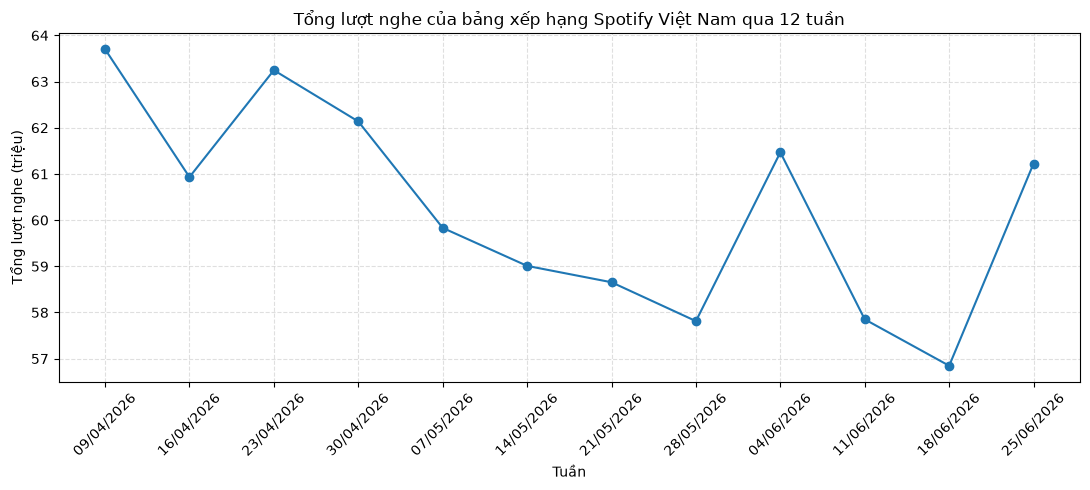

In [183]:
# Biểu đồ tổng lượt nghe của toàn bộ bảng xếp hạng qua 12 tuần
du_lieu_bieu_do_tuan = tong_quan_theo_tuan.copy()

du_lieu_bieu_do_tuan["Tuan_hien_thi"] = (
    du_lieu_bieu_do_tuan["chart_week"]
    .dt.strftime("%d/%m/%Y")
)

plt.figure(figsize=(11, 5))

plt.plot(
    du_lieu_bieu_do_tuan["Tuan_hien_thi"],
    du_lieu_bieu_do_tuan["tong_luot_nghe"] / 1_000_000,
    marker="o"
)

plt.xlabel("Tuần")
plt.ylabel("Tổng lượt nghe (triệu)")
plt.title("Tổng lượt nghe của bảng xếp hạng Spotify Việt Nam qua 12 tuần")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Trong 12 tuần khảo sát, tổng lượt nghe của bảng xếp hạng Spotify Việt Nam có sự biến động theo thời gian. Tổng lượt nghe đạt mức cao nhất vào tuần 09/04/2026 với khoảng 63,70 triệu lượt và giảm xuống mức thấp nhất vào tuần 18/06/2026 với khoảng 56,85 triệu lượt. Nhìn chung, lượt nghe có xu hướng giảm dần từ cuối tháng 4 đến cuối tháng 5, sau đó xuất hiện một số tuần tăng trở lại, nổi bật là ngày 04/06 và 25/06. Tuần 25/06 ghi nhận 40 bài mới hoặc quay lại bảng xếp hạng, cao nhất trong giai đoạn khảo sát, đồng thời tổng lượt nghe cũng tăng lên hơn 61,22 triệu lượt. Tuy nhiên, dữ liệu hiện tại chỉ cho thấy sự biến động, chưa đủ cơ sở để khẳng định số bài mới là nguyên nhân trực tiếp làm lượt nghe tăng.

### Top nghệ sĩ / nhóm nghệ sĩ nổi bật

In [184]:
top_nghe_si = df.groupby("artist_names").agg(
    tong_streams=("streams", "sum"),
    so_lan_xuat_hien=("track_name", "count"),
    so_bai_hat=("song_key", "nunique")
).reset_index()

top_nghe_si = top_nghe_si.sort_values("tong_streams", ascending=False).head(10)

display(top_nghe_si)

,artist_names,tong_streams,so_lan_xuat_hien,so_bai_hat
18,BTS,35674678,67,15
172,Sơn Tùng M-TP,27184362,92,12
82,"Jung Kook, Latto",27089117,12,1
59,HIEUTHUHAI,26702391,73,12
165,SOOBIN,22880476,73,7
55,GREY D,21971026,58,9
28,CORTIS,18529307,67,11
204,buitruonglinh,15326511,55,5
187,VCT,12451820,31,3
83,JustaTee,12184075,32,3


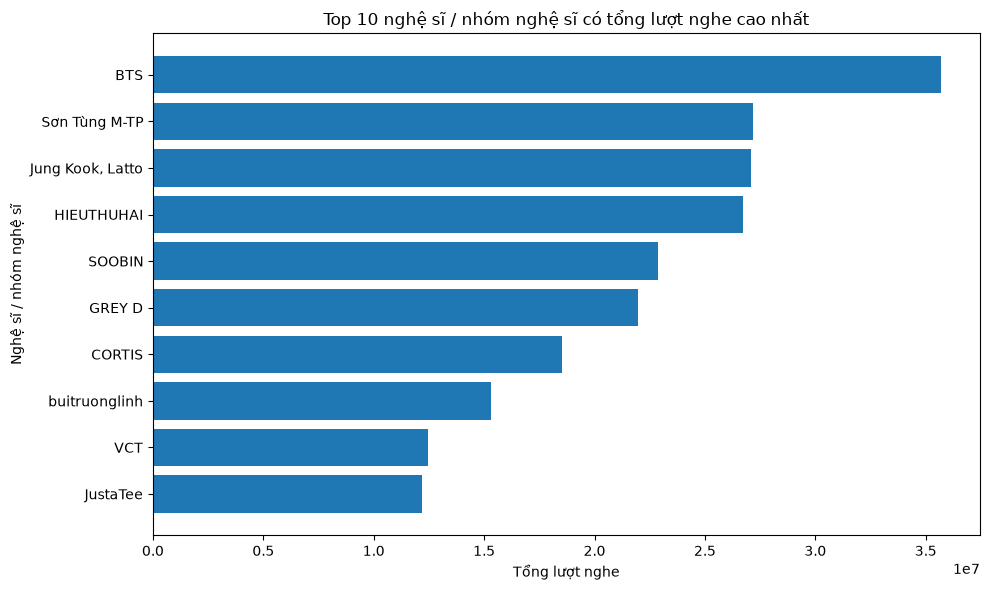

In [185]:
top_nghe_si_chart = top_nghe_si.sort_values("tong_streams", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_nghe_si_chart["artist_names"], top_nghe_si_chart["tong_streams"])
plt.xlabel("Tổng lượt nghe")
plt.ylabel("Nghệ sĩ / nhóm nghệ sĩ")
plt.title("Top 10 nghệ sĩ / nhóm nghệ sĩ có tổng lượt nghe cao nhất")
plt.tight_layout()
plt.show()

### Bài tăng hạng mạnh

In [186]:
bai_tang_hang_manh = df[df["rank_change"] > 0].copy()

bai_tang_hang_manh["Số hạng tăng"] = bai_tang_hang_manh["rank_change"].astype(int)

bai_tang_hang_manh = bai_tang_hang_manh.sort_values(
    by="Số hạng tăng",
    ascending=False
).head(10)

bai_tang_hang_manh = bai_tang_hang_manh[
    [
        "chart_week",
        "track_name",
        "artist_names",
        "previous_rank",
        "rank",
        "Số hạng tăng"
    ]
].rename(columns={
    "chart_week": "Tuần",
    "track_name": "Tên bài hát",
    "artist_names": "Nghệ sĩ",
    "previous_rank": "Hạng tuần trước",
    "rank": "Hạng hiện tại"
})

bai_tang_hang_manh["Tuần"] = bai_tang_hang_manh["Tuần"].dt.strftime("%Y-%m-%d")

bai_tang_hang_manh = bai_tang_hang_manh.reset_index(drop=True)
bai_tang_hang_manh.insert(0, "STT", range(1, len(bai_tang_hang_manh) + 1))

display(bai_tang_hang_manh.style.hide(axis="index"))

STT,Tuần,Tên bài hát,Nghệ sĩ,Hạng tuần trước,Hạng hiện tại,Số hạng tăng
1,2026-04-23,That Should Be Me,Justin Bieber,193,53,140
2,2026-06-04,Hững Hờ,Binz,184,56,128
3,2026-04-09,mới hôm qua,GREY D,138,34,104
4,2026-04-23,Love Yourself,Justin Bieber,180,86,94
5,2026-04-23,Sorry,Justin Bieber,175,84,91
6,2026-04-16,NGONGIODEMQUATRANGSANGDEMNAY,"RPT MCK, marzuz",146,60,86
7,2026-06-18,2.0,BTS,150,73,77
8,2026-04-23,Beauty And A Beat,"Justin Bieber, Nicki Minaj",86,9,77
9,2026-06-04,Nếu (feat. Obito),"Binz, Obito",114,37,77
10,2026-04-09,tựa đầu,GREY D,143,71,72


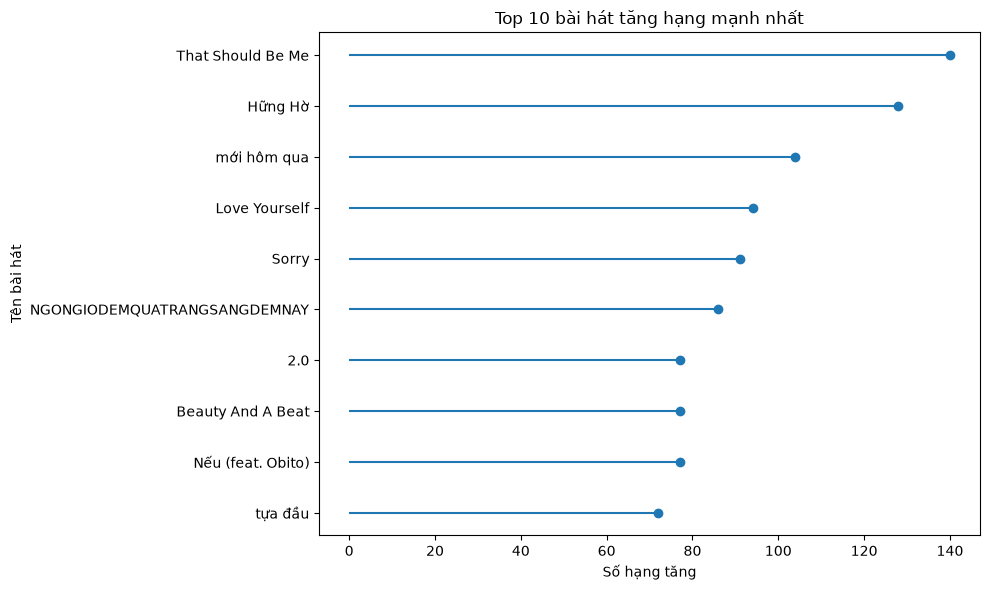

In [187]:
plt.figure(figsize=(10, 6))

ten_bai = bai_tang_hang_manh["Tên bài hát"][::-1]
so_hang_tang = bai_tang_hang_manh["Số hạng tăng"][::-1]

plt.hlines(y=ten_bai, xmin=0, xmax=so_hang_tang)
plt.plot(so_hang_tang, ten_bai, "o")

plt.xlabel("Số hạng tăng")
plt.ylabel("Tên bài hát")
plt.title("Top 10 bài hát tăng hạng mạnh nhất")
plt.tight_layout()
plt.show()

### Bài giữ phong độ ổn định

In [188]:
bai_on_dinh = df.groupby(["song_key", "track_name", "artist_names"]).agg(
    so_tuan_xuat_hien=("chart_week", "nunique"),
    hang_trung_binh=("rank", "mean"),
    do_lech_chuan_hang=("rank", "std"),
    hang_tot_nhat=("rank", "min"),
    tong_streams=("streams", "sum")
).reset_index()

bai_on_dinh = bai_on_dinh.sort_values(
    by=[
    "so_tuan_xuat_hien",
    "do_lech_chuan_hang",
    "hang_trung_binh",
    "tong_streams"
],
ascending=[False, True, True, False]
).head(10)

bai_on_dinh = bai_on_dinh.drop(columns=["song_key"]).rename(columns={
    "track_name": "Tên bài hát",
    "artist_names": "Nghệ sĩ",
    "so_tuan_xuat_hien": "Số tuần xuất hiện",
    "hang_trung_binh": "Hạng trung bình",
    "do_lech_chuan_hang": "Độ lệch chuẩn hạng",
    "hang_tot_nhat": "Hạng tốt nhất",
    "tong_streams": "Tổng lượt nghe"
})

bai_on_dinh = bai_on_dinh.reset_index(drop=True)
bai_on_dinh.insert(0, "STT", range(1, len(bai_on_dinh) + 1))

display(
    bai_on_dinh.style
    .hide(axis="index")
    .format({
        "Hạng trung bình": "{:.2f}",
        "Độ lệch chuẩn hạng": "{:.2f}",
        "Tổng lượt nghe": "{:,.0f}"
    })
)

STT,Tên bài hát,Nghệ sĩ,Số tuần xuất hiện,Hạng trung bình,Độ lệch chuẩn hạng,Hạng tốt nhất,Tổng lượt nghe
1,Seven (feat. Latto) (Explicit Ver.),"Jung Kook, Latto",12,1.08,0.29,1,"27,089,117"
2,SWIM,BTS,12,2.00,0.43,1,"23,474,764"
3,Không Buông,"Hngle, Ari",12,3.92,0.79,3,"10,843,431"
4,Exit Sign,"HIEUTHUHAI, marzuz",12,8.75,1.48,6,"7,923,976"
5,Và Thế Giới Đã Mất Đi Một Người Cô Đơn,"marzuz, Changg",12,10.58,2.47,7,"7,489,048"
6,Ngày Rời Chuyến Bay,"Minh Huy, Pinny",12,9.50,2.58,6,"7,710,886"
7,Người Im Lặng Gặp Người Hay Nói,HIEUTHUHAI,12,5.42,2.75,3,"9,961,545"
8,Mơ,VCT,12,17.33,3.20,12,"5,953,128"
9,In Love,"Low G, JustaTee",12,8.50,3.42,5,"8,257,400"
10,Âm Thầm Bên Em,Sơn Tùng M-TP,12,17.83,3.51,14,"5,993,078"


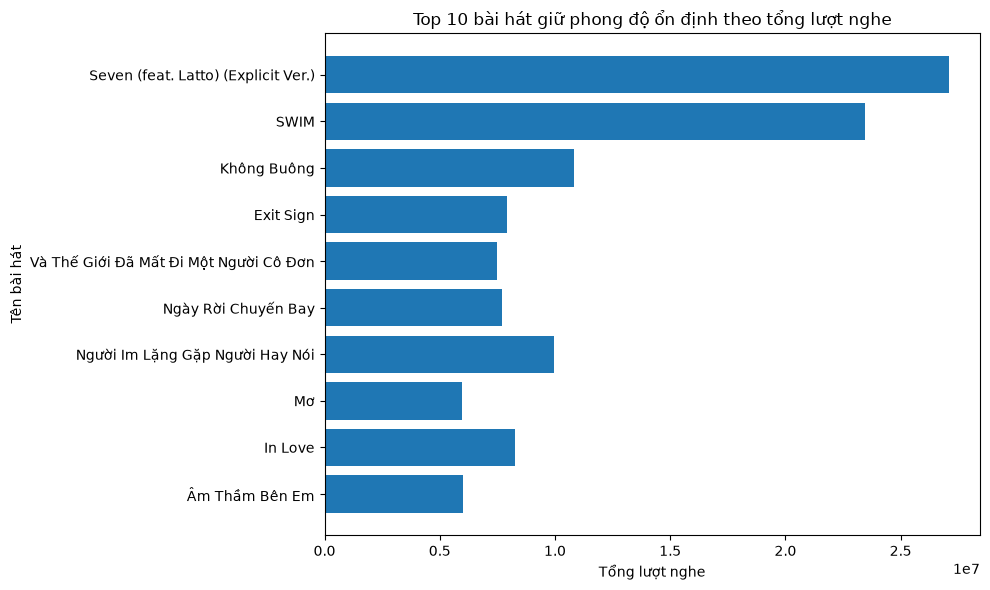

In [189]:
plt.figure(figsize=(10, 6))

plt.barh(
    bai_on_dinh["Tên bài hát"][::-1],
    bai_on_dinh["Tổng lượt nghe"][::-1]
)

plt.xlabel("Tổng lượt nghe")
plt.ylabel("Tên bài hát")
plt.title("Top 10 bài hát giữ phong độ ổn định theo tổng lượt nghe")
plt.tight_layout()
plt.show()

### Xu hướng lượt nghe qua 12 tuần

In [190]:
top_bai_xu_huong = df.groupby(["song_key", "track_name", "artist_names"]).agg(
    so_tuan_xuat_hien=("chart_week", "nunique"),
    tong_streams=("streams", "sum")
).reset_index()

top_bai_xu_huong = top_bai_xu_huong.sort_values(
    by=["so_tuan_xuat_hien", "tong_streams"],
    ascending=[False, False]
).head(5)

ds_song_key = top_bai_xu_huong["song_key"].tolist()

bang_top_bai_xu_huong = top_bai_xu_huong.drop(columns=["song_key"]).rename(columns={
    "track_name": "Tên bài hát",
    "artist_names": "Nghệ sĩ",
    "so_tuan_xuat_hien": "Số tuần xuất hiện",
    "tong_streams": "Tổng lượt nghe"
})

bang_top_bai_xu_huong = bang_top_bai_xu_huong.reset_index(drop=True)
bang_top_bai_xu_huong.insert(0, "STT", range(1, len(bang_top_bai_xu_huong) + 1))

display(
    bang_top_bai_xu_huong.style
    .hide(axis="index")
    .format({
        "Tổng lượt nghe": "{:,.0f}"
    })
)

STT,Tên bài hát,Nghệ sĩ,Số tuần xuất hiện,Tổng lượt nghe
1,Seven (feat. Latto) (Explicit Ver.),"Jung Kook, Latto",12,"27,089,117"
2,SWIM,BTS,12,"23,474,764"
3,Không Buông,"Hngle, Ari",12,"10,843,431"
4,Người Im Lặng Gặp Người Hay Nói,HIEUTHUHAI,12,"9,961,545"
5,In Love,"Low G, JustaTee",12,"8,257,400"


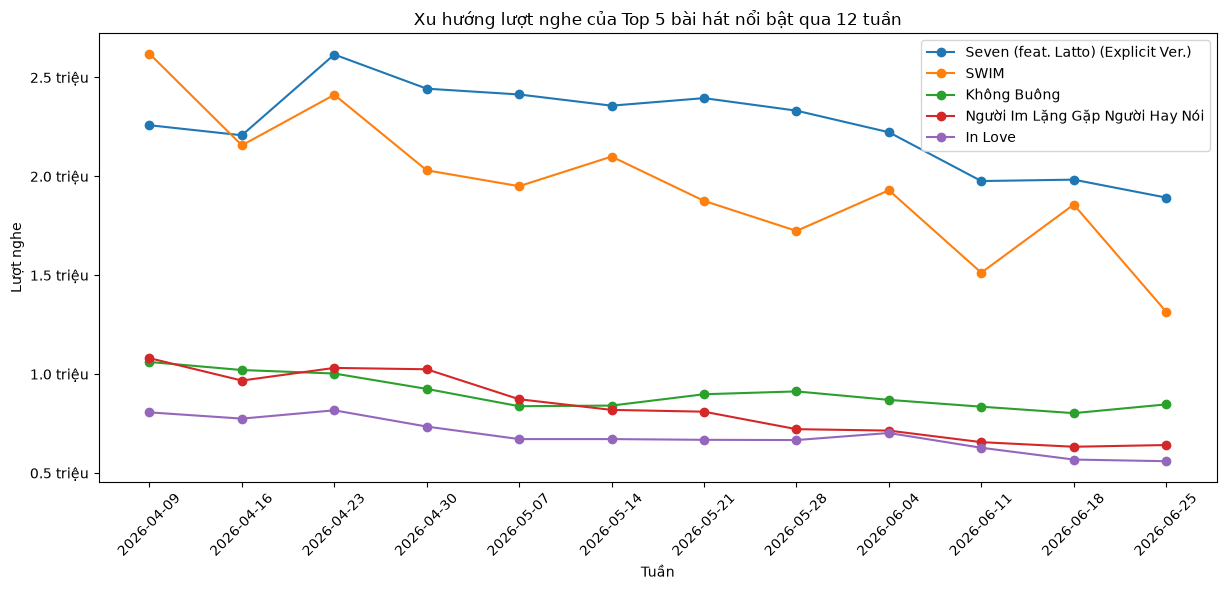

In [191]:
from matplotlib.ticker import FuncFormatter

du_lieu_xu_huong = df[df["song_key"].isin(ds_song_key)].copy()
du_lieu_xu_huong = du_lieu_xu_huong.sort_values(["song_key", "chart_week"])
du_lieu_xu_huong["Tuần"] = du_lieu_xu_huong["chart_week"].dt.strftime("%Y-%m-%d")

plt.figure(figsize=(12, 6))

for song_key in ds_song_key:
    bai = du_lieu_xu_huong[du_lieu_xu_huong["song_key"] == song_key].sort_values("chart_week")
    ten_bai = bai["track_name"].iloc[0]
    plt.plot(bai["Tuần"], bai["streams"], marker="o", label=ten_bai)

plt.xlabel("Tuần")
plt.ylabel("Lượt nghe")
plt.title("Xu hướng lượt nghe của Top 5 bài hát nổi bật qua 12 tuần")
plt.xticks(rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()

def dinh_dang_trieu(x, pos):
    return f"{x/1_000_000:.1f} triệu"

plt.gca().yaxis.set_major_formatter(FuncFormatter(dinh_dang_trieu))
plt.show()

### Chấm điểm bài hát đang có dấu hiệu tăng trưởng

---



Nhóm xây dựng điểm tiềm năng nhằm nhận diện các bài hát đang có dấu hiệu tăng trưởng tại tuần gần nhất. Điểm số được tính theo phương pháp trọng số do nhóm đề xuất, gồm:

- Lượt nghe hiện tại: 40%.
- Mức tăng hạng: 30%.
- Thứ hạng hiện tại: 20%.
- Độ mới dựa trên số tuần xuất hiện trên bảng xếp hạng: 10%.

Điểm tiềm năng có thang điểm tối đa là 100. Điểm càng cao cho thấy bài hát vừa có lượng nghe tương đối tốt, vừa có thứ hạng hoặc tốc độ tăng hạng đáng chú ý. Đây là phương pháp chấm điểm dựa trên dữ liệu hiện tại, không phải kết quả dự đoán của mô hình học máy.

In [192]:
tuan_moi_nhat = df["chart_week"].max()

bai_tiem_nang = df[
    (df["chart_week"] == tuan_moi_nhat) &
    (df["rank_change"] > 0)
].copy()

bai_tiem_nang["diem_luot_nghe"] = bai_tiem_nang["streams"] / bai_tiem_nang["streams"].max() * 40
bai_tiem_nang["diem_tang_hang"] = bai_tiem_nang["rank_change"] / bai_tiem_nang["rank_change"].max() * 30
bai_tiem_nang["diem_thu_hang"] = (201 - bai_tiem_nang["rank"]) / 200 * 20
bai_tiem_nang["diem_do_moi"] = (1 - (bai_tiem_nang["weeks_on_chart"] - 1) / (bai_tiem_nang["weeks_on_chart"].max() - 1)) * 10

bai_tiem_nang["diem_tiem_nang"] = (
    bai_tiem_nang["diem_luot_nghe"] +
    bai_tiem_nang["diem_tang_hang"] +
    bai_tiem_nang["diem_thu_hang"] +
    bai_tiem_nang["diem_do_moi"]
).round(2)

bai_tiem_nang = bai_tiem_nang.sort_values(
    by="diem_tiem_nang",
    ascending=False
).head(10)

bai_tiem_nang = bai_tiem_nang[
    [
        "chart_week",
        "track_name",
        "artist_names",
        "rank",
        "rank_change",
        "weeks_on_chart",
        "streams",
        "diem_tiem_nang"
    ]
].rename(columns={
    "chart_week": "Tuần",
    "track_name": "Tên bài hát",
    "artist_names": "Nghệ sĩ",
    "rank": "Hạng hiện tại",
    "rank_change": "Số hạng tăng",
    "weeks_on_chart": "Số tuần trên BXH",
    "streams": "Lượt nghe",
    "diem_tiem_nang": "Điểm tiềm năng"
})

bai_tiem_nang["Tuần"] = bai_tiem_nang["Tuần"].dt.strftime("%Y-%m-%d")
bai_tiem_nang["Số hạng tăng"] = bai_tiem_nang["Số hạng tăng"].astype(int)

bai_tiem_nang = bai_tiem_nang.reset_index(drop=True)
bai_tiem_nang.insert(0, "STT", range(1, len(bai_tiem_nang) + 1))

display(
    bai_tiem_nang.style
    .hide(axis="index")
    .format({
        "Lượt nghe": "{:,.0f}",
        "Điểm tiềm năng": "{:.2f}"
    })
)

STT,Tuần,Tên bài hát,Nghệ sĩ,Hạng hiện tại,Số hạng tăng,Số tuần trên BXH,Lượt nghe,Điểm tiềm năng
1,2026-06-25,Người Im Lặng Gặp Người Hay Nói,HIEUTHUHAI,9,2,16,"640,492",69.79
2,2026-06-25,toidaidot,GREY D,14,1,3,"595,561",66.47
3,2026-06-25,vết thương,Fishy,16,1,58,"590,946",63.09
4,2026-06-25,Exit Sign,"HIEUTHUHAI, marzuz",8,1,141,"640,784",62.63
5,2026-06-25,yêu em như…,GREY D,129,43,13,"211,317",59.76
6,2026-06-25,Người Đáng Thương Là Anh,Only C,102,33,23,"240,846",56.80
7,2026-06-25,REDRED,CORTIS,25,1,10,"459,647",56.52
8,2026-06-25,FaSHioN,CORTIS,141,39,29,"202,741",54.39
9,2026-06-25,TNT,CORTIS,113,30,8,"229,389",53.68
10,2026-06-25,Buông,Hngle,85,14,19,"263,255",46.85


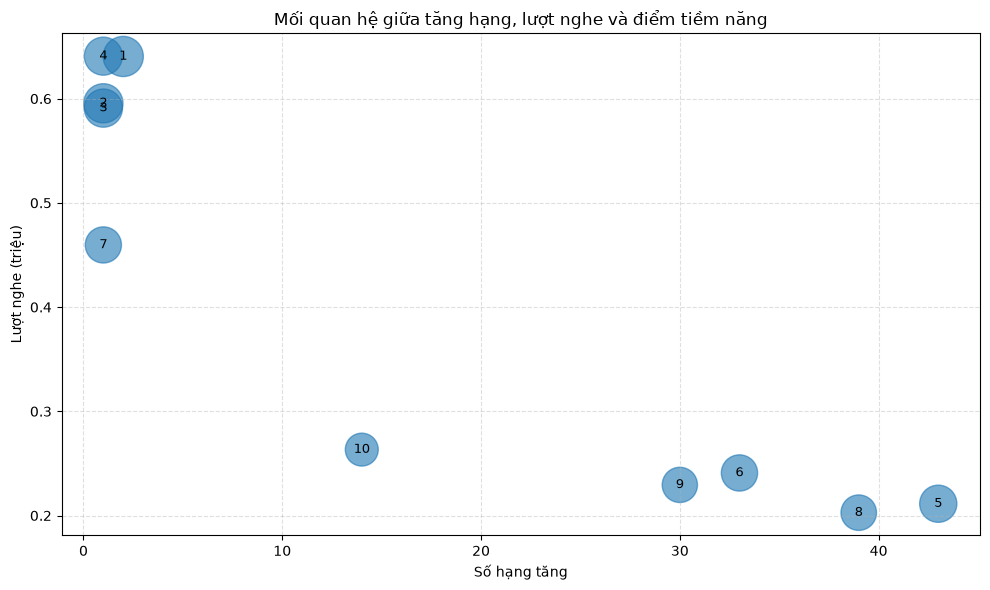

In [193]:
bieu_do_tiem_nang = bai_tiem_nang.copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    bieu_do_tiem_nang["Số hạng tăng"],
    bieu_do_tiem_nang["Lượt nghe"] / 1_000_000,
    s=bieu_do_tiem_nang["Điểm tiềm năng"] * 12,
    alpha=0.6
)

for i, row in bieu_do_tiem_nang.iterrows():
    plt.text(
        row["Số hạng tăng"],
        row["Lượt nghe"] / 1_000_000,
        str(row["STT"]),
        fontsize=9,
        ha="center",
        va="center"
    )

plt.xlabel("Số hạng tăng")
plt.ylabel("Lượt nghe (triệu)")
plt.title("Mối quan hệ giữa tăng hạng, lượt nghe và điểm tiềm năng")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#### Nhận xét

Kết quả chấm điểm tại tuần 25/06/2026 cho thấy “Người Im Lặng Gặp Người Hay Nói” của HIEUTHUHAI đứng đầu với 69,79 điểm. Bài hát đang giữ vị trí thứ 9, tăng 2 bậc và đạt hơn 640 nghìn lượt nghe. Điều này cho thấy bài hát vừa có mức độ phổ biến cao, vừa tiếp tục duy trì xu hướng tăng hạng.

“toidaidot” của GREY D đứng thứ hai với 66,47 điểm. Bài hát mới xuất hiện trên bảng xếp hạng được 3 tuần nhưng đã đạt vị trí thứ 14 và gần 596 nghìn lượt nghe. Đây là trường hợp đáng chú ý do đạt thứ hạng cao trong thời gian tương đối ngắn.

Một số bài như “yêu em như…”, “Người Đáng Thương Là Anh” và “FaSHioN” chưa có thứ hạng cao, nhưng lại tăng lần lượt 43, 33 và 39 bậc. Những trường hợp này thể hiện tốc độ cải thiện thứ hạng mạnh và có thể tiếp tục được theo dõi trong các tuần sau.

Nhìn chung, bảng kết quả phản ánh hai dạng bài hát tiềm năng: các bài đã có lượt nghe và thứ hạng cao; và các bài chưa đứng ở nhóm đầu nhưng đang tăng hạng nhanh. Tuy nhiên, điểm tiềm năng chỉ phản ánh dữ liệu tại thời điểm hiện tại, chưa thể khẳng định lượt nghe của bài hát chắc chắn tiếp tục tăng trong tuần kế tiếp.

#### Ý nghĩa ứng dụng

Kết quả chấm điểm giúp nhóm sàng lọc ban đầu những bài hát đang có dấu hiệu tăng trưởng. Các bài có điểm tiềm năng cao có thể được cân nhắc đưa vào danh sách phát, quảng bá trên mạng xã hội hoặc lựa chọn cho các hoạt động truyền thông.

Đối với bài hát đã có lượt nghe và thứ hạng cao, hoạt động marketing có thể tập trung vào việc duy trì sức hút. Đối với bài hát chưa có thứ hạng cao nhưng đang tăng hạng nhanh, đơn vị phát hành có thể xem xét quảng bá sớm để tận dụng đà tăng trưởng.

Tuy nhiên, điểm tiềm năng chỉ phản ánh dữ liệu ở thời điểm hiện tại và được tính theo trọng số do nhóm đề xuất. Ở bước tiếp theo, kết quả này sẽ được kết hợp với mô hình dự đoán lượt nghe tuần sau để lựa chọn các bài hát đáng chú ý hơn.

#### Kiểm tra điểm tiềm năng trên các tuần trước (Backtest)

Để kiểm tra điểm tiềm năng có phản ánh khả năng tăng trưởng hay không, nhóm áp dụng lại cùng công thức chấm điểm cho các tuần trước và đối chiếu với kết quả của tuần kế tiếp. Việc kiểm tra tập trung vào khả năng bài hát tiếp tục xuất hiện trong Top 200 và đồng thời tăng lượt nghe ở tuần sau.

In [194]:
# Backtest điểm tiềm năng trên các tuần đã có dữ liệu tuần kế tiếp

ket_qua_backtest = []

cac_tuan = sorted(df["chart_week"].unique())

# Bỏ tuần cuối vì không có dữ liệu thực tế của tuần kế tiếp
for tuan in cac_tuan[:-1]:

    # Giữ đúng phạm vi như công thức hiện tại:
    # chỉ xét các bài đang tăng hạng
    du_lieu_tuan = df[
        (df["chart_week"] == tuan) &
        (df["rank_change"] > 0)
    ].copy()

    if du_lieu_tuan.empty:
        continue

    # Giữ nguyên công thức điểm tiềm năng hiện tại
    du_lieu_tuan["diem_luot_nghe"] = (
        du_lieu_tuan["streams"]
        / du_lieu_tuan["streams"].max()
        * 40
    )

    du_lieu_tuan["diem_tang_hang"] = (
        du_lieu_tuan["rank_change"]
        / du_lieu_tuan["rank_change"].max()
        * 30
    )

    du_lieu_tuan["diem_thu_hang"] = (
        (201 - du_lieu_tuan["rank"])
        / 200
        * 20
    )

    max_weeks = du_lieu_tuan["weeks_on_chart"].max()

    if max_weeks > 1:
        du_lieu_tuan["diem_do_moi"] = (
            1
            - (du_lieu_tuan["weeks_on_chart"] - 1)
            / (max_weeks - 1)
        ) * 10
    else:
        du_lieu_tuan["diem_do_moi"] = 10

    du_lieu_tuan["diem_tiem_nang"] = (
        du_lieu_tuan["diem_luot_nghe"]
        + du_lieu_tuan["diem_tang_hang"]
        + du_lieu_tuan["diem_thu_hang"]
        + du_lieu_tuan["diem_do_moi"]
    )

    # Xếp hạng theo điểm tiềm năng trong từng tuần
    du_lieu_tuan["xep_hang_tiem_nang"] = (
        du_lieu_tuan["diem_tiem_nang"]
        .rank(method="first", ascending=False)
    )

    # Lấy dữ liệu thực tế của tuần tiếp theo
    tuan_sau = pd.Timestamp(tuan) + pd.Timedelta(days=7)

    du_lieu_tuan_sau = df[
        df["chart_week"] == tuan_sau
    ][["uri", "streams"]].rename(columns={
        "streams": "streams_tuan_sau"
    })

    du_lieu_tuan = du_lieu_tuan.merge(
        du_lieu_tuan_sau,
        on="uri",
        how="left"
    )

    # Thành công = vẫn còn trong Top 200 và lượt nghe tăng
    du_lieu_tuan["con_trong_top200_tuan_sau"] = (
        du_lieu_tuan["streams_tuan_sau"].notna()
    )

    du_lieu_tuan["tang_luot_nghe_tuan_sau"] = (
        du_lieu_tuan["con_trong_top200_tuan_sau"]
        & (du_lieu_tuan["streams_tuan_sau"] > du_lieu_tuan["streams"])
    )

    ket_qua_backtest.append(
        du_lieu_tuan[
            [
                "chart_week",
                "uri",
                "track_name",
                "artist_names",
                "diem_tiem_nang",
                "xep_hang_tiem_nang",
                "con_trong_top200_tuan_sau",
                "tang_luot_nghe_tuan_sau"
            ]
        ]
    )

backtest_tiem_nang = pd.concat(
    ket_qua_backtest,
    ignore_index=True
)

print("Số trường hợp dùng để backtest:", len(backtest_tiem_nang))
display(backtest_tiem_nang.head())

Số trường hợp dùng để backtest: 852


,chart_week,uri,track_name,artist_names,diem_tiem_nang,xep_hang_tiem_nang,con_trong_top200_tuan_sau,tang_luot_nghe_tuan_sau
0,2026-04-09,spotify:track:11T61UpoNbbcewOMl1kcWN,Dạo Bước HongKong 1999,NHONHO,71.016927,2.0,True,False
1,2026-04-09,spotify:track:42AOwjuMmIN1ioyyWB60Lw,hoá ra…,GREY D,69.794798,3.0,True,False
2,2026-04-09,spotify:track:6Qwl74olNi1rl65FNxG5We,Và Thế Giới Đã Mất Đi Một Người Cô Đơn,"marzuz, Changg",54.148620,7.0,True,True
3,2026-04-09,spotify:track:3vSmjbKFByNM6l31NmFlmB,đôi mắt kẻ tình si,"GREY D, MIN",63.245616,4.0,True,False
4,2026-04-09,spotify:track:1FUdEz4fX1DxPcVAARlu6A,yêu em như…,GREY D,58.501187,5.0,True,False


In [195]:
# So sánh Top 10 điểm tiềm năng với các bài còn lại

backtest_tiem_nang["Nhóm"] = np.where(
    backtest_tiem_nang["xep_hang_tiem_nang"] <= 10,
    "Top 10 điểm tiềm năng",
    "Các bài còn lại"
)

tong_hop_backtest = (
    backtest_tiem_nang
    .groupby("Nhóm")
    .agg(
        so_truong_hop=("uri", "count"),
        ty_le_con_top200=(
            "con_trong_top200_tuan_sau",
            "mean"
        ),
        ty_le_tang_luot_nghe=(
            "tang_luot_nghe_tuan_sau",
            "mean"
        )
    )
    .reset_index()
)

tong_hop_backtest["ty_le_con_top200"] *= 100
tong_hop_backtest["ty_le_tang_luot_nghe"] *= 100

tong_hop_backtest = tong_hop_backtest.rename(columns={
    "so_truong_hop": "Số trường hợp",
    "ty_le_con_top200": "Tỷ lệ còn trong Top 200 (%)",
    "ty_le_tang_luot_nghe": "Tỷ lệ tăng lượt nghe tuần sau (%)"
})

display(
    tong_hop_backtest.style
    .hide(axis="index")
    .format({
        "Tỷ lệ còn trong Top 200 (%)": "{:.2f}",
        "Tỷ lệ tăng lượt nghe tuần sau (%)": "{:.2f}"
    })
)

Nhóm,Số trường hợp,Tỷ lệ còn trong Top 200 (%),Tỷ lệ tăng lượt nghe tuần sau (%)
Các bài còn lại,742,94.20,38.41
Top 10 điểm tiềm năng,110,97.27,34.55


#### Nhận xét kết quả Backtest

Kết quả backtest cho thấy nhóm Top 10 bài hát có điểm tiềm năng cao có tỷ lệ tiếp tục xuất hiện trong Top 200 ở tuần kế tiếp đạt 97,27%, cao hơn mức 94,20% của các bài còn lại. Điều này cho thấy điểm tiềm năng có khả năng hỗ trợ sàng lọc các bài hát có sức duy trì tốt trên bảng xếp hạng.

Tuy nhiên, tỷ lệ tăng lượt nghe ở tuần kế tiếp của nhóm Top 10 đạt 34,55%, thấp hơn mức 38,41% của các bài còn lại. Vì vậy, điểm tiềm năng hiện tại chưa đủ để xem là công cụ dự đoán tăng trưởng lượt nghe. Trong bước tiếp theo, điểm số này sẽ được kết hợp với kết quả dự đoán của mô hình học máy để nhận diện các bài hát đáng chú ý hơn.

# Top 10 bài hát có lượt nghe cao

In [196]:
tong_luot_nghe = df.groupby(['track_name', 'artist_names'])['streams'].sum().reset_index()

top_luot_nghe_cao_nhat = tong_luot_nghe.sort_values(by='streams', ascending=False).head(10)

top_luot_nghe_cao_nhat = top_luot_nghe_cao_nhat[
    [
        "track_name",
        "artist_names",
        "streams",
    ]
].rename(columns={
    "track_name": "Tên bài hát",
    "artist_names": "Nghệ sĩ",
    "streams": "Lượt nghe"
})

display(
    top_luot_nghe_cao_nhat.style
    .hide(axis="index")
    .format({
        "Lượt nghe": "{:,.0f}"
    })
)

Tên bài hát,Nghệ sĩ,Lượt nghe
Seven (feat. Latto) (Explicit Ver.),"Jung Kook, Latto","27,089,117"
SWIM,BTS,"23,474,764"
Không Buông,"Hngle, Ari","10,843,431"
Người Im Lặng Gặp Người Hay Nói,HIEUTHUHAI,"9,961,545"
In Love,"Low G, JustaTee","8,257,400"
Standing Next to You,Jung Kook,"7,966,564"
Exit Sign,"HIEUTHUHAI, marzuz","7,923,976"
Ngày Rời Chuyến Bay,"Minh Huy, Pinny","7,710,886"
Và Thế Giới Đã Mất Đi Một Người Cô Đơn,"marzuz, Changg","7,489,048"
dự báo thời tiết hôm nay mưa,GREY D,"6,741,924"


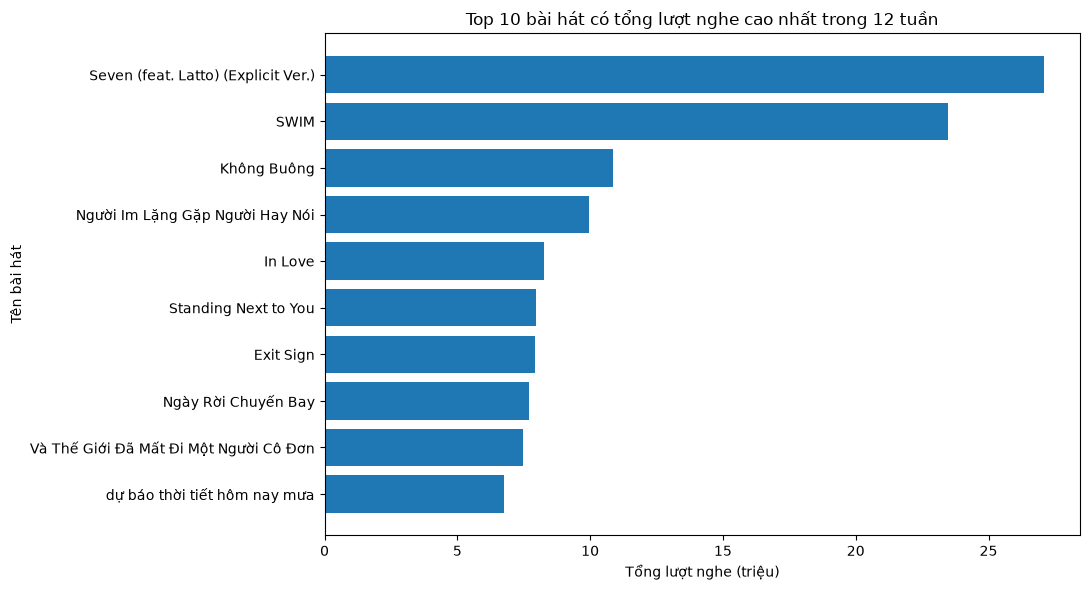

In [197]:
bieu_do_top_luot_nghe = top_luot_nghe_cao_nhat.sort_values(
    "Lượt nghe",
    ascending=True
)

plt.figure(figsize=(11, 6))

plt.barh(
    bieu_do_top_luot_nghe["Tên bài hát"],
    bieu_do_top_luot_nghe["Lượt nghe"] / 1_000_000
)

plt.xlabel("Tổng lượt nghe (triệu)")
plt.ylabel("Tên bài hát")
plt.title("Top 10 bài hát có tổng lượt nghe cao nhất trong 12 tuần")

plt.tight_layout()
plt.show()

# Phân tích thể loại nhạc

In [198]:
tong_theo_the_loai = df.groupby('genre').agg(
    tong_luot_nghe=('streams', 'sum'),
    so_lan_xuat_hien=('track_name', 'count')
).reset_index()

tong_theo_the_loai = tong_theo_the_loai.sort_values(by='tong_luot_nghe', ascending=False)

tong_theo_the_loai = tong_theo_the_loai.rename(columns={
    "genre": "Thể loại",
    "tong_luot_nghe": "Tổng lượt nghe",
    "so_lan_xuat_hien": "Số lần xuất hiện (track-tuần)"
})

display(
    tong_theo_the_loai.style
    .hide(axis="index")
    .format({
        "Tổng lượt nghe": "{:,.0f}"
    })
)

Thể loại,Tổng lượt nghe,Số lần xuất hiện (track-tuần)
Pop,"167,433,947",438
Ballad,"154,291,720",514
Rap/Hip-hop,"144,120,821",508
R&B/Soul,"125,452,153",442
Indie/Alternative,"103,916,266",408
EDM/Dance,"19,782,190",61
Khác,"7,718,887",29


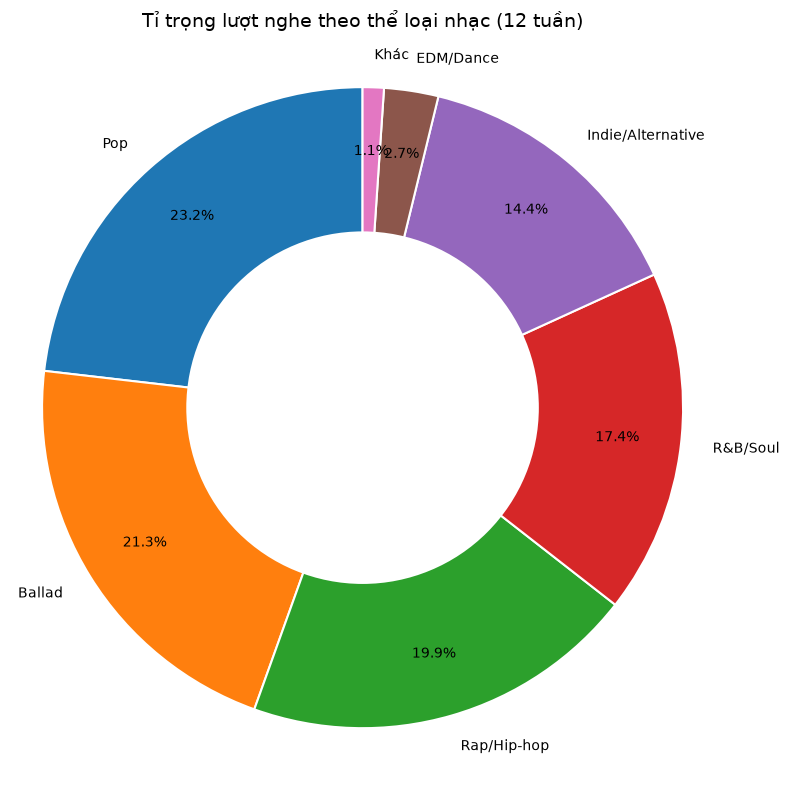

In [199]:
plt.figure(figsize=(8, 8))

colors = sns.color_palette(n_colors=len(tong_theo_the_loai))

plt.pie(
    tong_theo_the_loai['Tổng lượt nghe'],
    labels=tong_theo_the_loai['Thể loại'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Tỉ trọng lượt nghe theo thể loại nhạc (12 tuần)', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [200]:
from scipy.interpolate import make_interp_spline

weekly = df.groupby(['chart_week', 'genre'])['streams'].sum().unstack(fill_value=0)
weekly_share = (weekly.div(weekly.sum(axis=1), axis=0) * 100).round(1)

display(weekly_share.style.format("{:.1f}%"))

genre,Ballad,EDM/Dance,Indie/Alternative,Khác,Pop,R&B/Soul,Rap/Hip-hop
chart_week,,,,,,,
2026-04-09 00:00:00,21.5%,1.2%,18.8%,0.9%,21.5%,16.3%,19.7%
2026-04-16 00:00:00,22.7%,2.2%,17.1%,0.9%,20.1%,17.1%,19.9%
2026-04-23 00:00:00,21.4%,3.7%,16.2%,0.9%,22.8%,15.9%,19.1%
2026-04-30 00:00:00,20.4%,2.6%,16.0%,1.2%,21.6%,15.9%,22.2%
2026-05-07 00:00:00,21.3%,2.1%,15.1%,1.3%,25.2%,15.4%,19.6%
2026-05-14 00:00:00,21.9%,1.7%,14.1%,1.0%,26.2%,15.8%,19.3%
2026-05-21 00:00:00,21.9%,1.6%,14.1%,1.3%,25.8%,15.6%,19.7%
2026-05-28 00:00:00,21.5%,1.5%,14.0%,1.1%,24.1%,18.1%,19.7%
2026-06-04 00:00:00,20.5%,5.5%,11.7%,1.0%,24.6%,19.3%,17.4%


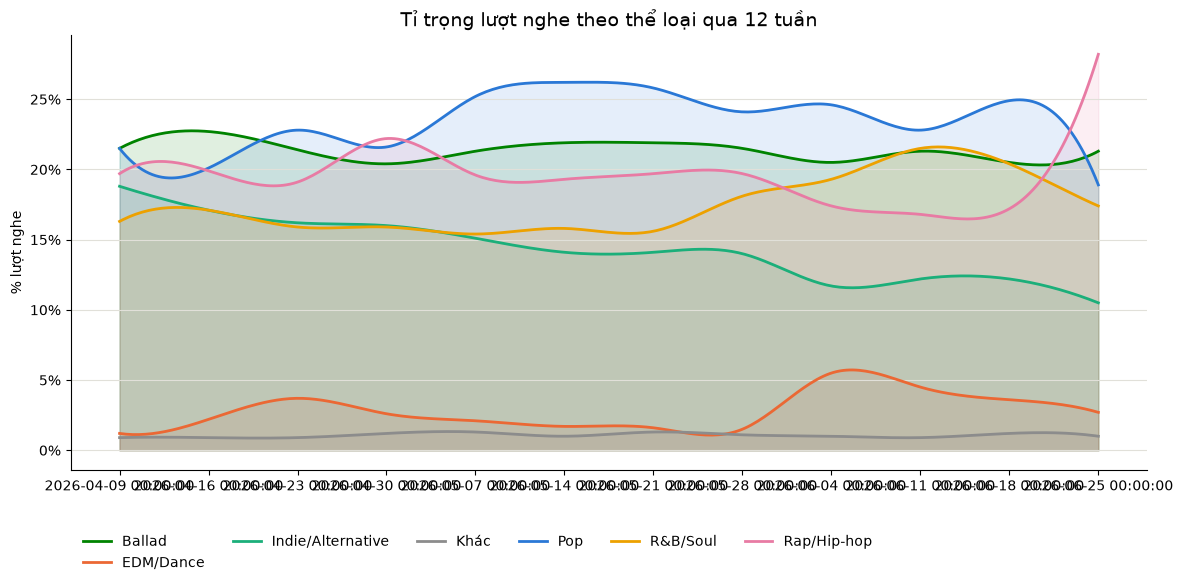

In [201]:
mau_theo_the_loai = {
    'Pop': '#2a78d6',
    'Ballad': '#008300',
    'Rap/Hip-hop': '#e87ba4',
    'R&B/Soul': '#eda100',
    'Indie/Alternative': '#1baf7a',
    'EDM/Dance': '#eb6834',
    'Khác': '#8C8C8C'
}

x = np.arange(len(weekly_share.index))
x_smooth = np.linspace(x.min(), x.max(), 300)

plt.figure(figsize=(12, 6))

for the_loai in weekly_share.columns:
    y = weekly_share[the_loai].values
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_smooth)

    mau = mau_theo_the_loai.get(the_loai, '#999999')
    plt.plot(x_smooth, y_smooth, color=mau, linewidth=2, label=the_loai)
    plt.fill_between(x_smooth, y_smooth, color=mau, alpha=0.12)

plt.title('Tỉ trọng lượt nghe theo thể loại qua 12 tuần', fontsize=14)
plt.ylabel('% lượt nghe')
plt.xticks(x, weekly_share.index, rotation=0)
plt.gca().yaxis.set_major_formatter(lambda v, pos: f'{int(v)}%')
plt.grid(axis='y', color='#e1e0d9', linewidth=0.8)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=6, frameon=False)
plt.tight_layout()
plt.show()

Bài tụt hạng mạnh

In [202]:
latest_week = df['chart_week'].max()
lw = df[df['chart_week'] == latest_week].copy()

top_tut_hang = (
    lw[lw["rank_change"] < 0]
    .sort_values(by="rank_change")
    .head(10)
)

top_tut_hang = top_tut_hang[
    [
        "track_name",
        "artist_names",
        "previous_rank",
        "rank",
        "rank_change",
        "streams",
        "genre",
    ]
].rename(columns={
    "track_name": "Tên bài hát",
    "artist_names": "Nghệ sĩ",
    "previous_rank": "Hạng tuần trước",
    "rank": "Hạng hiện tại",
    "rank_change": "Số bậc thay đổi",
    "streams": "Lượt nghe",
    "genre": "Thể loại"
})

display(
    top_tut_hang.style
    .hide(axis="index")
    .format({
        "Lượt nghe": "{:,.0f}",
        "Số bậc thay đổi": "{:.0f}"
    })
)

Tên bài hát,Nghệ sĩ,Hạng tuần trước,Hạng hiện tại,Số bậc thay đổi,Lượt nghe,Thể loại
2.0,BTS,73,182,-109,"176,677",Rap/Hip-hop
Hãy Trao Cho Anh,"Sơn Tùng M-TP, Snoop Dogg",80,170,-90,"188,446",EDM/Dance
Nếu Những Tiếc Nuối,Vũ.,102,184,-82,"175,576",Indie/Alternative
Em Của Anh Đừng Của Ai!,Long Cao,121,200,-79,"167,804",Pop
"Hẹn Một Mai - From"" 4 Năm 2 Chàng 1 Tình Yêu""",Bùi Anh Tuấn,115,189,-74,"171,289",Ballad
Em Còn Nhớ Anh Không - Remastered,"Hoàng Tôn, Koo",112,175,-63,"182,643",Ballad
có hẹn với thanh xuân,"MONSTAR, GREY D, VƯƠNG BÌNH",111,167,-56,"190,732",R&B/Soul
Trở Về,"Wxrdie, JustaTee",110,166,-56,"191,338",Rap/Hip-hop
thế giới của anh,"Dangrangto, DONAL",122,176,-54,"181,651",Indie/Alternative
Hẹn Lần Sau,MAYDAYs,97,148,-51,"199,297",Indie/Alternative


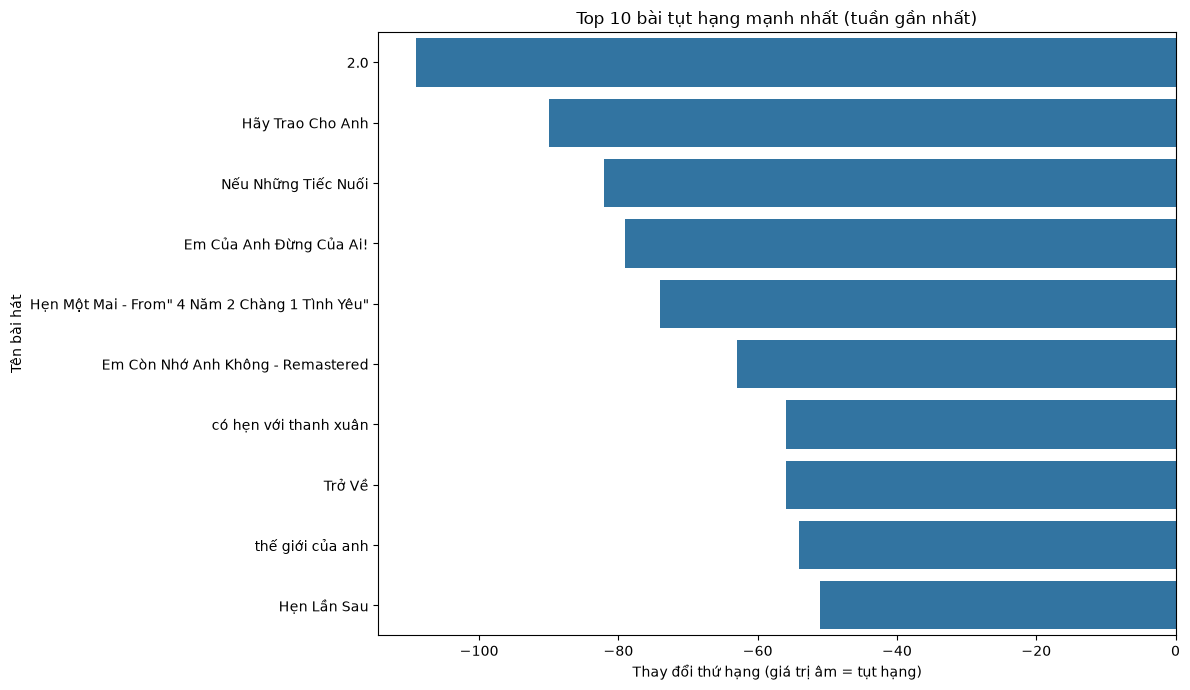

In [203]:
bieu_do_tut_hang = top_tut_hang.copy()
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Số bậc thay đổi', y='Tên bài hát',
    data=bieu_do_tut_hang
)
plt.title('Top 10 bài tụt hạng mạnh nhất (tuần gần nhất)')
plt.xlabel('Thay đổi thứ hạng (giá trị âm = tụt hạng)')
plt.ylabel('Tên bài hát')
plt.tight_layout()
plt.show()

Trong tuần 25/06/2026, “2.0” của BTS là bài tụt hạng mạnh nhất, từ vị trí 73 xuống vị trí 182, tương ứng giảm 109 bậc. Lượt nghe của bài cũng giảm từ 257.792 xuống còn 176.677 lượt, tương đương khoảng 31,5% so với tuần trước.

“Hãy Trao Cho Anh” của Sơn Tùng M-TP và Snoop Dogg giảm từ vị trí 80 xuống vị trí 170, tương ứng giảm 90 bậc. Đồng thời, lượt nghe giảm từ 247.473 xuống 188.446 lượt, tương đương khoảng 23,9%.

Kết quả cho thấy sự giảm thứ hạng của hai bài hát đi kèm với sự suy giảm lượt nghe. Bên cạnh đó, tuần 25/06 cũng xuất hiện 40 bài mới hoặc quay lại bảng xếp hạng, làm mức độ cạnh tranh giữa các bài hát tăng lên. Tuy nhiên, dữ liệu hiện có chưa đủ để xác định chính xác nguyên nhân khiến từng bài hát bị giảm lượt nghe và thứ hạng.

Bài mới hoặc quay lại BXH

In [204]:
bai_moi_moi_tuan = df[df['is_new_entry']].groupby('chart_week').size().reset_index(name='so_bai_moi')

display(bai_moi_moi_tuan.rename(columns={
    "chart_week": "Tuần",
    "so_bai_moi": "Số bài mới hoặc quay lại"
}).style.hide(axis="index"))

Tuần,Số bài mới hoặc quay lại
2026-04-09 00:00:00,13
2026-04-16 00:00:00,17
2026-04-23 00:00:00,15
2026-04-30 00:00:00,23
2026-05-07 00:00:00,18
2026-05-14 00:00:00,12
2026-05-21 00:00:00,17
2026-05-28 00:00:00,12
2026-06-04 00:00:00,20
2026-06-11 00:00:00,16


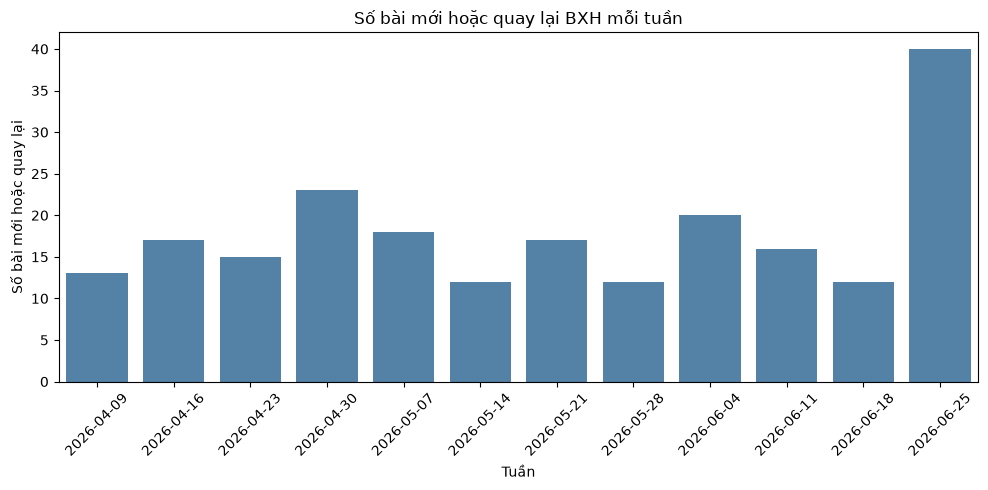

In [205]:
plt.figure(figsize=(10, 5))
sns.barplot(x='chart_week', y='so_bai_moi', data=bai_moi_moi_tuan, color='steelblue')
plt.title('Số bài mới hoặc quay lại BXH mỗi tuần')
plt.xlabel('Tuần')
plt.ylabel('Số bài mới hoặc quay lại')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [206]:
bai_moi_tuan_gan_nhat = df[(df['chart_week'] == latest_week) & (df['is_new_entry'])].sort_values('rank')

bai_moi_tuan_gan_nhat = bai_moi_tuan_gan_nhat[
    ["rank", "track_name", "artist_names", "streams", "genre"]
].rename(columns={
    "rank": "Hạng",
    "track_name": "Tên bài hát",
    "artist_names": "Nghệ sĩ",
    "streams": "Lượt nghe",
    "genre": "Thể loại"
})

display(
    bai_moi_tuan_gan_nhat.style
    .hide(axis="index")
    .format({"Lượt nghe": "{:,.0f}"})
)

Hạng,Tên bài hát,Nghệ sĩ,Lượt nghe,Thể loại
3,Tìm Em (feat. Bảo Anh),"Hngle, Bảo Anh","983,192",Ballad
6,Nếu Như Ta Chẳng Còn (feat. A$AP Ướt Mi),"RPT MCK, A$AP Ướt Mi","764,524",Ballad
10,Mắt Môi Tay Chân (feat. Tage),"RPT MCK, Tage","632,121",Rap/Hip-hop
12,Nguyễn Văn Mười,RPT MCK,"614,944",Rap/Hip-hop
18,xương rồng (intro),"Dangrangto, DONAL","551,367",Indie/Alternative
21,Liệm,RPT MCK,"475,941",Rap/Hip-hop
23,Anh Không Muốn Nó Dễ Dàng,RPT MCK,"465,905",Rap/Hip-hop
26,Xa Xôi (feat. Obito),"RPT MCK, Obito","453,628",Rap/Hip-hop
27,IDK,RPT MCK,"452,002",Rap/Hip-hop
28,Baby (feat. marzuz),"RPT MCK, marzuz","450,024",Rap/Hip-hop


Trong 40 bài hát mới hoặc quay lại bảng xếp hạng ở tuần 25/06/2026, có 23 bài do RPT MCK đứng tên riêng và 7 bài hợp tác có sự tham gia của RPT MCK. Như vậy, tổng cộng 30/40 bài mới trong tuần có sự góp mặt của RPT MCK, chiếm 75%. Kết quả này cho thấy các sản phẩm của RPT MCK xuất hiện với mật độ lớn và tạo ra sự thay đổi đáng kể trong cơ cấu bảng xếp hạng tuần 25/06/2026.

# TUẦN 4: XÂY DỰNG MÔ HÌNH DỰ ĐOÁN LƯỢT NGHE

## 2.4. Lựa chọn và huấn luyện mô hình

### 1. Chuẩn bị dữ liệu cho mô hình

In [207]:
# Tạo bản sao riêng để chuẩn bị dữ liệu cho mô hình
model_df = df.copy()

# Sắp xếp theo bài hát và thời gian
# Dùng uri để xác định chính xác từng bài hát
model_df = model_df.sort_values(
    by=["uri", "chart_week"]
).reset_index(drop=True)

# Tạo số thứ tự tuần từ 1 đến 12
danh_sach_tuan = sorted(model_df["chart_week"].unique())

week_mapping = {
    week: index + 1
    for index, week in enumerate(danh_sach_tuan)
}

model_df["week_index"] = model_df["chart_week"].map(week_mapping)

display(
    model_df[
        [
            "chart_week",
            "week_index",
            "track_name",
            "artist_names",
            "uri",
            "streams"
        ]
    ].head(10)
)

,chart_week,week_index,track_name,artist_names,uri,streams
0,2026-04-09,1,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",spotify:track:01qFKNWq73UfEslI0GvumE,281238
1,2026-04-16,2,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",spotify:track:01qFKNWq73UfEslI0GvumE,376800
2,2026-04-23,3,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",spotify:track:01qFKNWq73UfEslI0GvumE,417210
3,2026-04-30,4,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",spotify:track:01qFKNWq73UfEslI0GvumE,366869
4,2026-05-07,5,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",spotify:track:01qFKNWq73UfEslI0GvumE,317591
5,2026-05-14,6,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",spotify:track:01qFKNWq73UfEslI0GvumE,304308
6,2026-05-21,7,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",spotify:track:01qFKNWq73UfEslI0GvumE,319626
7,2026-05-28,8,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",spotify:track:01qFKNWq73UfEslI0GvumE,299419
8,2026-06-04,9,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",spotify:track:01qFKNWq73UfEslI0GvumE,268667
9,2026-06-11,10,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",spotify:track:01qFKNWq73UfEslI0GvumE,261685


In [208]:
# Lấy tuần tiếp theo của cùng một bài hát
model_df["next_chart_week"] = (
    model_df.groupby("uri")["chart_week"].shift(-1)
)

# Lấy lượt nghe ở lần xuất hiện tiếp theo của cùng bài hát
model_df["streams_next_week"] = (
    model_df.groupby("uri")["streams"].shift(-1)
)

# Tính khoảng cách giữa hai tuần
model_df["days_to_next_week"] = (
    model_df["next_chart_week"] - model_df["chart_week"]
).dt.days

In [209]:
# Chỉ giữ trường hợp bài hát xuất hiện ở tuần kế tiếp,
# tức hai lần ghi nhận cách nhau đúng 7 ngày
model_df = model_df[
    model_df["days_to_next_week"] == 7
].copy()

model_df = model_df.reset_index(drop=True)

print("Số dòng dữ liệu ban đầu:", len(df))
print("Số dòng dùng để huấn luyện mô hình:", len(model_df))
print(
    "Số giá trị thiếu ở streams_next_week:",
    model_df["streams_next_week"].isnull().sum()
)

display(
    model_df[
        [
            "chart_week",
            "week_index",
            "track_name",
            "artist_names",
            "streams",
            "next_chart_week",
            "streams_next_week"
        ]
    ].head(10)
)

Số dòng dữ liệu ban đầu: 2400
Số dòng dùng để huấn luyện mô hình: 1975
Số giá trị thiếu ở streams_next_week: 0


,chart_week,week_index,track_name,artist_names,streams,next_chart_week,streams_next_week
0,2026-04-09,1,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",281238,2026-04-16,376800.0
1,2026-04-16,2,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",376800,2026-04-23,417210.0
2,2026-04-23,3,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",417210,2026-04-30,366869.0
3,2026-04-30,4,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",366869,2026-05-07,317591.0
4,2026-05-07,5,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",317591,2026-05-14,304308.0
5,2026-05-14,6,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",304308,2026-05-21,319626.0
6,2026-05-21,7,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",319626,2026-05-28,299419.0
7,2026-05-28,8,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",299419,2026-06-04,268667.0
8,2026-06-04,9,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",268667,2026-06-11,261685.0
9,2026-06-11,10,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow",261685,2026-06-18,269549.0


#### Phạm vi dự đoán của mô hình

Dữ liệu Spotify Top 200 chỉ ghi nhận lượt nghe của các bài hát còn xuất hiện trong bảng xếp hạng. Vì vậy, `streams_next_week` chỉ được xác định đối với các bài hát tiếp tục xuất hiện trong Top 200 ở tuần kế tiếp.

Do đó, mô hình trong nghiên cứu này dự đoán lượt nghe tuần tiếp theo với điều kiện bài hát vẫn tiếp tục nằm trong Top 200. Các bài hát rời khỏi bảng xếp hạng không được xem là có 0 lượt nghe, vì dữ liệu hiện tại không cung cấp lượt nghe thực tế của các bài này sau khi rời Top 200.

### 2. Chuẩn bị biến đầu vào và chia dữ liệu

In [210]:
# Xử lý dữ liệu trước khi đưa vào mô hình

# previous_rank = -1 nghĩa là không có hạng ở tuần trước.
# Đổi thành 201 để biểu thị vị trí ngoài Top 200.
model_df["previous_rank_model"] = (
    model_df["previous_rank"].replace(-1, 201)
)

# Bài mới không tính được rank_change nên thay bằng 0.
# Cột is_new_entry vẫn giúp mô hình nhận biết đây là bài mới hoặc quay lại BXH.
model_df["rank_change_model"] = (
    model_df["rank_change"].fillna(0)
)

# Chuyển True/False thành 1/0
model_df["is_new_entry_model"] = (
    model_df["is_new_entry"].astype(int)
)

# Các biến số
numeric_features = [
    "rank",
    "previous_rank_model",
    "peak_rank",
    "weeks_on_chart",
    "streams",
    "rank_change_model",
    "is_new_entry_model",
    "week_index"
]

# Biến phân loại
categorical_features = ["genre"]

# Biến cần dự đoán
target = "streams_next_week"

print("Các biến số:")
print(numeric_features)

print("\nBiến phân loại:")
print(categorical_features)

print("\nBiến mục tiêu:")
print(target)

Các biến số:
['rank', 'previous_rank_model', 'peak_rank', 'weeks_on_chart', 'streams', 'rank_change_model', 'is_new_entry_model', 'week_index']

Biến phân loại:
['genre']

Biến mục tiêu:
streams_next_week


In [211]:
# Kiểm tra dữ liệu thiếu trong các biến dùng cho mô hình
columns_for_model = (
    numeric_features
    + categorical_features
    + [target]
)

missing_values = (
    model_df[columns_for_model]
    .isnull()
    .sum()
    .to_frame(name="Số giá trị thiếu")
)

display(missing_values)

,Số giá trị thiếu
rank,0
previous_rank_model,0
peak_rank,0
weeks_on_chart,0
streams,0
rank_change_model,0
is_new_entry_model,0
week_index,0
genre,0
streams_next_week,0


In [212]:
# Chia train/test theo thời gian

train_df = model_df[
    model_df["week_index"] <= 9
].copy()

test_df = model_df[
    model_df["week_index"] >= 10
].copy()

X_train = train_df[
    numeric_features + categorical_features
].copy()

X_test = test_df[
    numeric_features + categorical_features
].copy()

y_train = train_df[target].copy()
y_test = test_df[target].copy()

print("Số dòng tập train:", len(train_df))
print("Số dòng tập test:", len(test_df))

print(
    "\nCác tuần dùng làm đầu vào tập train:",
    sorted(train_df["week_index"].unique())
)

print(
    "Các tuần dùng làm đầu vào tập test:",
    sorted(test_df["week_index"].unique())
)

print("\nKhoảng thời gian tập test:")
print(
    test_df[
        ["chart_week", "next_chart_week"]
    ]
    .drop_duplicates()
    .sort_values("chart_week")
)

Số dòng tập train: 1632
Số dòng tập test: 343

Các tuần dùng làm đầu vào tập train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Các tuần dùng làm đầu vào tập test: [np.int64(10), np.int64(11)]

Khoảng thời gian tập test:
   chart_week next_chart_week
9  2026-06-11      2026-06-18
10 2026-06-18      2026-06-25


### 3. Xây dựng mô hình Baseline

Baseline sử dụng lượt nghe của tuần hiện tại làm giá trị dự đoán cho tuần kế tiếp. Mô hình này được dùng làm mốc cơ sở để đánh giá Linear Regression và Random Forest có cải thiện kết quả dự đoán hay không.

In [213]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Baseline: lượt nghe tuần sau bằng lượt nghe tuần hiện tại
y_pred_baseline = test_df["streams"].copy()

# Tính các chỉ số đánh giá
baseline_mae = mean_absolute_error(
    y_test,
    y_pred_baseline
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)

baseline_r2 = r2_score(
    y_test,
    y_pred_baseline
)

baseline_result = pd.DataFrame({
    "Mô hình": ["Baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R²": [baseline_r2]
})

display(
    baseline_result.style
    .hide(axis="index")
    .format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R²": "{:.4f}"
    })
)

Mô hình,MAE,RMSE,R²
Baseline,"24,989.82","53,903.49",0.9341


### 4. Xây dựng mô hình Linear Regression

Các biến số được chuẩn hóa bằng StandardScaler. Biến thể loại âm nhạc được chuyển đổi bằng One-Hot Encoding. Toàn bộ quá trình tiền xử lý và huấn luyện được kết hợp trong một Pipeline để bảo đảm tập train và tập test được xử lý theo cùng một quy trình.

In [214]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Tiền xử lý dữ liệu
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "genre",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Pipeline gồm tiền xử lý và Linear Regression
linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Huấn luyện mô hình
linear_regression_model.fit(X_train, y_train)

print("Đã huấn luyện mô hình Linear Regression.")

Đã huấn luyện mô hình Linear Regression.


In [215]:
# Dự đoán lượt nghe tuần tiếp theo
y_pred_linear = linear_regression_model.predict(X_test)

# Tính các chỉ số đánh giá
linear_mae = mean_absolute_error(
    y_test,
    y_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

linear_r2 = r2_score(
    y_test,
    y_pred_linear
)

linear_result = pd.DataFrame({
    "Mô hình": ["Linear Regression"],
    "MAE": [linear_mae],
    "RMSE": [linear_rmse],
    "R²": [linear_r2]
})

display(
    linear_result.style
    .hide(axis="index")
    .format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R²": "{:.4f}"
    })
)

print(
    "Giá trị dự đoán nhỏ nhất:",
    f"{y_pred_linear.min():,.2f}"
)

Mô hình,MAE,RMSE,R²
Linear Regression,"23,833.79","48,788.66",0.9460


Giá trị dự đoán nhỏ nhất: 142,217.39


In [216]:
# So sánh Baseline và Linear Regression
comparison_phung = pd.concat(
    [
        baseline_result,
        linear_result
    ],
    ignore_index=True
)

display(
    comparison_phung.style
    .hide(axis="index")
    .format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R²": "{:.4f}"
    })
)

Mô hình,MAE,RMSE,R²
Baseline,"24,989.82","53,903.49",0.9341
Linear Regression,"23,833.79","48,788.66",0.9460


In [217]:
# Bảng xem thử kết quả dự đoán
linear_prediction_table = test_df[
    [
        "chart_week",
        "next_chart_week",
        "track_name",
        "artist_names",
        "streams",
        "streams_next_week"
    ]
].copy()

linear_prediction_table["linear_prediction"] = y_pred_linear

linear_prediction_table["absolute_error"] = abs(
    linear_prediction_table["streams_next_week"]
    - linear_prediction_table["linear_prediction"]
)

linear_prediction_table = linear_prediction_table.rename(
    columns={
        "chart_week": "Tuần hiện tại",
        "next_chart_week": "Tuần cần dự đoán",
        "track_name": "Bài hát",
        "artist_names": "Nghệ sĩ",
        "streams": "Lượt nghe hiện tại",
        "streams_next_week": "Lượt nghe thực tế tuần sau",
        "linear_prediction": "Linear Regression dự đoán",
        "absolute_error": "Sai lệch tuyệt đối"
    }
)

display(
    linear_prediction_table.head(10).style
    .format({
        "Lượt nghe hiện tại": "{:,.0f}",
        "Lượt nghe thực tế tuần sau": "{:,.0f}",
        "Linear Regression dự đoán": "{:,.0f}",
        "Sai lệch tuyệt đối": "{:,.0f}"
    })
)

,Tuần hiện tại,Tuần cần dự đoán,Bài hát,Nghệ sĩ,Lượt nghe hiện tại,Lượt nghe thực tế tuần sau,Linear Regression dự đoán,Sai lệch tuyệt đối
9,2026-06-11 00:00:00,2026-06-18 00:00:00,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow","261,685","269,549","261,801","7,748"
10,2026-06-18 00:00:00,2026-06-25 00:00:00,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow","269,549","243,026","268,976","25,950"
28,2026-06-11 00:00:00,2026-06-18 00:00:00,vạn vật như muốn ta bên nhau,RIO,"235,528","215,182","222,389","7,207"
29,2026-06-18 00:00:00,2026-06-25 00:00:00,vạn vật như muốn ta bên nhau,RIO,"215,182","207,117","203,529","3,588"
30,2026-06-11 00:00:00,2026-06-18 00:00:00,toidaidot,GREY D,"391,626","529,918","416,462","113,456"
40,2026-06-11 00:00:00,2026-06-18 00:00:00,Em Đừng Khóc,Chillies,"223,286","204,681","212,177","7,496"
41,2026-06-18 00:00:00,2026-06-25 00:00:00,Em Đừng Khóc,Chillies,"204,681","202,576","193,951","8,625"
51,2026-06-11 00:00:00,2026-06-18 00:00:00,Trạng Thái Mộng Mơ,Đỗ Hoàng Long,"169,732","162,607","158,294","4,313"
63,2026-06-11 00:00:00,2026-06-18 00:00:00,She Neva Knows,JustaTee,"529,316","463,070","502,689","39,619"
64,2026-06-18 00:00:00,2026-06-25 00:00:00,She Neva Knows,JustaTee,"463,070","487,217","440,335","46,882"


In [218]:
# Kiểm tra Linear Regression có dự đoán lượt nghe âm hay không
so_du_doan_am = (y_pred_linear < 0).sum()

print("Số giá trị dự đoán âm:", so_du_doan_am)
print(
    "Giá trị dự đoán nhỏ nhất:",
    f"{y_pred_linear.min():,.2f}"
)

Số giá trị dự đoán âm: 0
Giá trị dự đoán nhỏ nhất: 142,217.39


#### Nhận xét kết quả

Mô hình Linear Regression đạt MAE là 23.833,79 và RMSE là 48.788,66, thấp hơn so với Baseline. Đồng thời, hệ số R² của Linear Regression đạt 0,9460, cao hơn mức 0,9341 của Baseline. Kết quả cho thấy Linear Regression đã cải thiện khả năng dự đoán lượt nghe tuần kế tiếp so với việc chỉ sử dụng lượt nghe tuần hiện tại làm giá trị dự đoán.

Cụ thể, Linear Regression giảm MAE khoảng 4,63% và giảm RMSE khoảng 9,49% so với Baseline. Tuy nhiên, mức cải thiện MAE chưa quá lớn vì lượt nghe giữa hai tuần liên tiếp thường có tính ổn định tương đối cao, khiến Baseline cũng đạt kết quả tốt.

Mô hình vẫn gặp khó khăn đối với những bài hát có lượt nghe biến động đột ngột. Chẳng hạn, “toidaidot” tăng từ 391.626 lượt nghe lên 529.918 lượt nghe nhưng mô hình chỉ dự đoán khoảng 416.462 lượt, tạo ra sai lệch hơn 113 nghìn lượt. Điều này cho thấy mô hình tuyến tính chưa phản ánh tốt các trường hợp tăng trưởng bất thường.

In [219]:
# Lưu kết quả của Phụng để lát nữa ghép với Random Forest
ket_qua_phung = pd.DataFrame({
    "Mô hình": [
        "Baseline",
        "Linear Regression"
    ],
    "MAE": [
        baseline_mae,
        linear_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse
    ],
    "R²": [
        baseline_r2,
        linear_r2
    ]
})

display(
    ket_qua_phung.style
    .hide(axis="index")
    .format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R²": "{:.4f}"
    })
)

Mô hình,MAE,RMSE,R²
Baseline,"24,989.82","53,903.49",0.9341
Linear Regression,"23,833.79","48,788.66",0.9460


### 5. Xây dựng mô hình Random Forest Regressor




In [220]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Pipeline gồm tiền xử lý và Random Forest
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100, #sử dụng 100 cây quyết định
                random_state=42 #cố định kết quả để mỗi lần chạy đều giống nhau
            )
        )
    ]
)

# Huấn luyện mô hình
random_forest_model.fit(
    X_train,
    y_train
)

print("Đã huấn luyện Random Forest Regressor.")

Đã huấn luyện Random Forest Regressor.


In [221]:
#dự đoán trên tập dữ liệu test
y_pred_rf = random_forest_model.predict(X_test)


rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

rf_r2 = r2_score(
    y_test,
    y_pred_rf
)

rf_result = pd.DataFrame({
    "Mô hình": ["Random Forest"],
    "MAE": [rf_mae],
    "RMSE": [rf_rmse],
    "R²": [rf_r2]
})

display(
    rf_result.style
    .hide(axis="index")
    .format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R²": "{:.4f}"
    })
)

Mô hình,MAE,RMSE,R²
Random Forest,"29,998.37","64,808.76",0.9048


In [222]:
# Kết quả dự đoán của mô  Random Forest
rf_prediction_table = test_df[
    [
        "chart_week",
        "next_chart_week",
        "track_name",
        "artist_names",
        "streams",
        "streams_next_week"
    ]
].copy()

rf_prediction_table["rf_prediction"] = y_pred_rf

rf_prediction_table["absolute_error"] = abs(
    rf_prediction_table["streams_next_week"]
    - rf_prediction_table["rf_prediction"]
)

rf_prediction_table = rf_prediction_table.rename(
    columns={
        "chart_week": "Tuần hiện tại",
        "next_chart_week": "Tuần cần dự đoán",
        "track_name": "Bài hát",
        "artist_names": "Nghệ sĩ",
        "streams": "Lượt nghe hiện tại",
        "streams_next_week": "Lượt nghe thực tế tuần sau",
        "rf_prediction": "Random Forest dự đoán",
        "absolute_error": "Sai lệch tuyệt đối"
    }
)

display(
    rf_prediction_table.head(10).style
    .format({
        "Lượt nghe hiện tại": "{:,.0f}",
        "Lượt nghe thực tế tuần sau": "{:,.0f}",
        "Random Forest dự đoán": "{:,.0f}",
        "Sai lệch tuyệt đối": "{:,.0f}"
    })
)

,Tuần hiện tại,Tuần cần dự đoán,Bài hát,Nghệ sĩ,Lượt nghe hiện tại,Lượt nghe thực tế tuần sau,Random Forest dự đoán,Sai lệch tuyệt đối
9,2026-06-11 00:00:00,2026-06-18 00:00:00,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow","261,685","269,549","267,976","1,573"
10,2026-06-18 00:00:00,2026-06-25 00:00:00,3D (feat. Jack Harlow),"Jung Kook, Jack Harlow","269,549","243,026","281,520","38,494"
28,2026-06-11 00:00:00,2026-06-18 00:00:00,vạn vật như muốn ta bên nhau,RIO,"235,528","215,182","234,567","19,385"
29,2026-06-18 00:00:00,2026-06-25 00:00:00,vạn vật như muốn ta bên nhau,RIO,"215,182","207,117","249,807","42,690"
30,2026-06-11 00:00:00,2026-06-18 00:00:00,toidaidot,GREY D,"391,626","529,918","372,513","157,405"
40,2026-06-11 00:00:00,2026-06-18 00:00:00,Em Đừng Khóc,Chillies,"223,286","204,681","230,633","25,952"
41,2026-06-18 00:00:00,2026-06-25 00:00:00,Em Đừng Khóc,Chillies,"204,681","202,576","237,113","34,537"
51,2026-06-11 00:00:00,2026-06-18 00:00:00,Trạng Thái Mộng Mơ,Đỗ Hoàng Long,"169,732","162,607","179,520","16,913"
63,2026-06-11 00:00:00,2026-06-18 00:00:00,She Neva Knows,JustaTee,"529,316","463,070","521,848","58,778"
64,2026-06-18 00:00:00,2026-06-25 00:00:00,She Neva Knows,JustaTee,"463,070","487,217","435,386","51,831"


#### Nhận xét kết quả
Kết quả dự đoán cho thấy Random Forest Regressor có khả năng dự báo khá tốt đối với các bài hát có lượt nghe ổn định qua các tuần. Nhiều bài hát có sai lệch dự đoán dưới 20.000 lượt nghe, chứng tỏ mô hình đã học được mối quan hệ giữa các đặc trưng đầu vào và lượt nghe của tuần tiếp theo. Tuy nhiên, mô hình vẫn gặp khó khăn đối với những bài hát có mức tăng hoặc giảm lượt nghe đột ngột, dẫn đến sai số lớn ở một số trường hợp. Điều này làm cho giá trị RMSE tăng đáng kể so với MAE.

### Biểu đồ so sánh 3 mô hình với dữ liệu thực tế

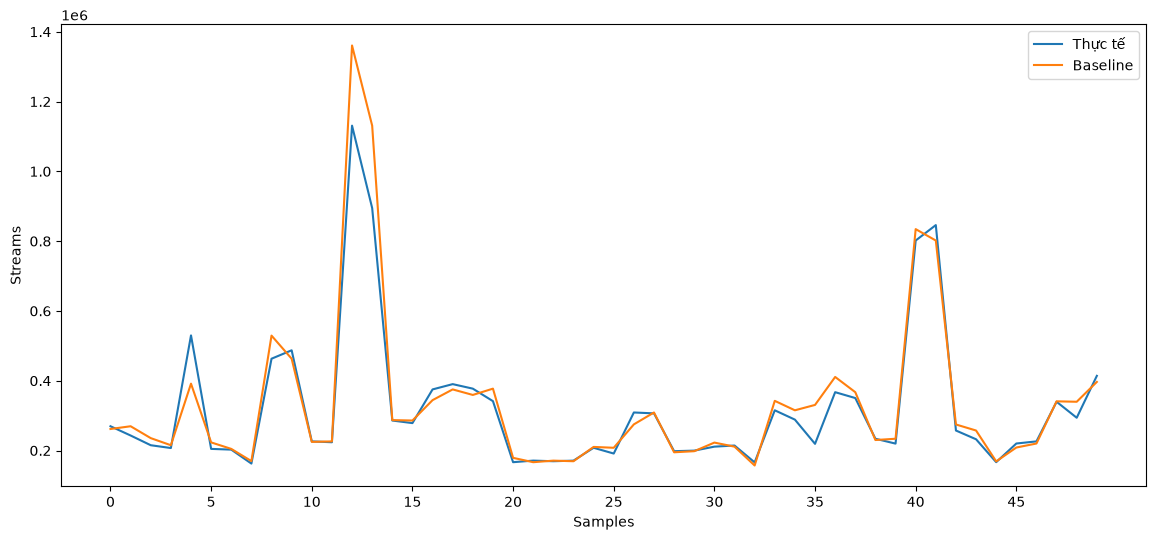

In [223]:
import matplotlib.pyplot as plt

n = 50

plt.figure(figsize=(14,6))

x = range(n)

plt.plot(x, y_test.values[:n], label="Thực tế")
plt.plot(x, y_pred_baseline[:n], label="Baseline")

plt.xticks(range(0, n, 5))
plt.xlabel("Samples")
plt.ylabel("Streams")
plt.legend()
plt.show()

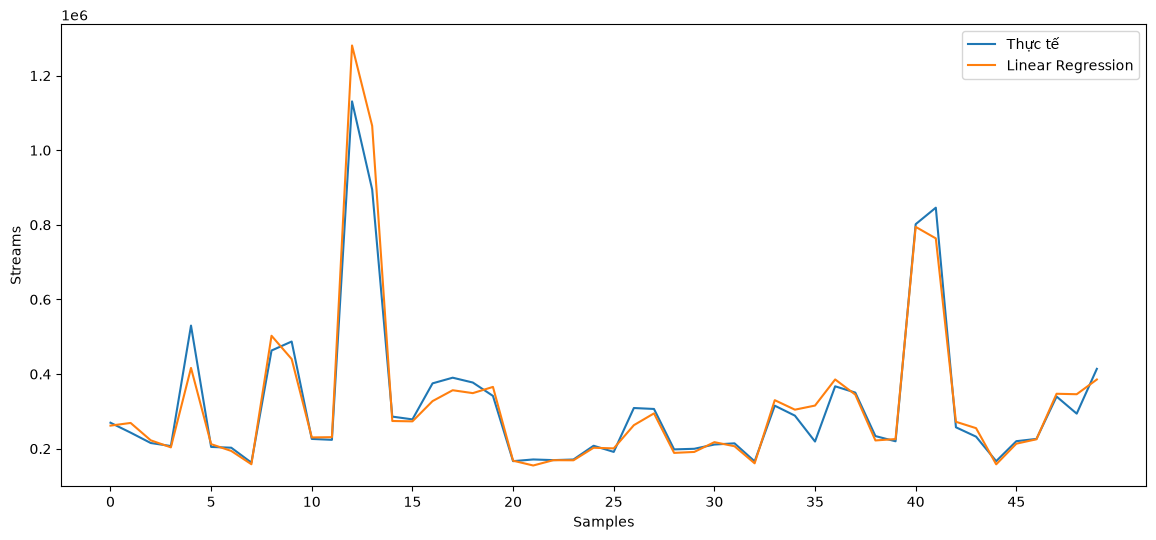

In [224]:
import matplotlib.pyplot as plt

n = 50

plt.figure(figsize=(14,6))

x = range(n)

plt.plot(x, y_test.values[:n], label="Thực tế")
plt.plot(x, y_pred_linear[:n], label="Linear Regression")

plt.xticks(range(0, n, 5))
plt.xlabel("Samples")
plt.ylabel("Streams")
plt.legend()
plt.show()

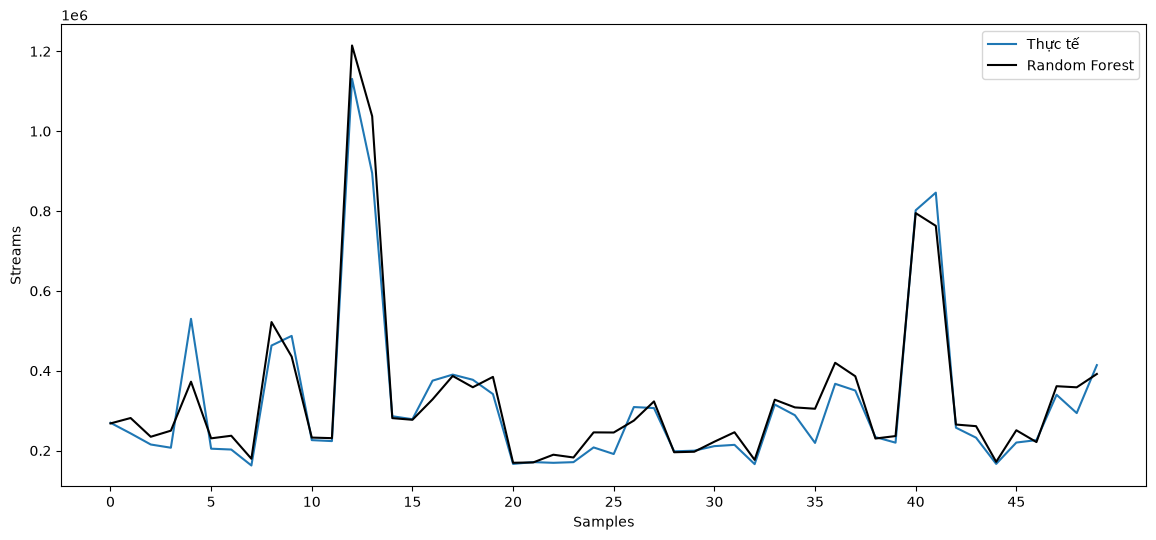

In [225]:
import matplotlib.pyplot as plt

n = 50

plt.figure(figsize=(14,6))

x = range(n)

plt.plot(x, y_test.values[:n], label="Thực tế")
plt.plot(x, y_pred_rf[:n], label="Random Forest",color="black")

plt.xticks(range(0, n, 5))
plt.xlabel("Samples")
plt.ylabel("Streams")
plt.legend()
plt.show()

### Chọn mô hình tốt hơn

Chọn theo nguyên tắc:

MAE nhỏ nhất,
RMSE nhỏ nhất,
R² lớn nhất

In [226]:
comparison_table = pd.concat(
    [
        baseline_result,
        linear_result,
        rf_result
    ],
    ignore_index=True
)

display(
    comparison_table.style
    .hide(axis="index")
    .format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R²": "{:.4f}"
    })
)

Mô hình,MAE,RMSE,R²
Baseline,"24,989.82","53,903.49",0.9341
Linear Regression,"23,833.79","48,788.66",0.9460
Random Forest,"29,998.37","64,808.76",0.9048


-> Linear Regression là mô hình tốt nhất

### Dự báo lượt nghe cho tuần kế tiếp

Sau khi lựa chọn Linear Regression là mô hình có kết quả tốt nhất, nhóm huấn luyện lại mô hình trên toàn bộ dữ liệu đã có nhãn và sử dụng dữ liệu của tuần gần nhất (25/06/2026) để dự báo lượt nghe cho tuần 02/07/2026.

Kết quả dự báo được hiểu với điều kiện bài hát tiếp tục xuất hiện trong Spotify Top 200 ở tuần kế tiếp.

In [227]:
from sklearn.base import clone

# Huấn luyện lại Linear Regression trên toàn bộ dữ liệu đã có nhãn
X_all = model_df[
    numeric_features + categorical_features
].copy()

y_all = model_df[target].copy()

final_linear_model = clone(linear_regression_model)

final_linear_model.fit(
    X_all,
    y_all
)

# Lấy dữ liệu tuần gần nhất
latest_week = df["chart_week"].max()
future_week = latest_week + pd.Timedelta(days=7)

future_df = df[
    df["chart_week"] == latest_week
].copy()

# Tạo các biến giống lúc huấn luyện mô hình
future_df["previous_rank_model"] = (
    future_df["previous_rank"].replace(-1, 201)
)

future_df["rank_change_model"] = (
    future_df["rank_change"].fillna(0)
)

future_df["is_new_entry_model"] = (
    future_df["is_new_entry"].astype(int)
)

# Tuần 25/06 là tuần thứ 12 trong dữ liệu
future_df["week_index"] = max(
    week_mapping.values()
)

# Chuẩn bị dữ liệu đầu vào
X_future = future_df[
    numeric_features + categorical_features
].copy()

# Dự báo lượt nghe tuần kế tiếp
future_df["predicted_streams_next_week"] = (
    final_linear_model.predict(X_future)
)

# Lượt nghe không thể âm
future_df["predicted_streams_next_week"] = (
    future_df["predicted_streams_next_week"]
    .clip(lower=0)
)

# Tính % thay đổi dự kiến
future_df["predicted_growth_pct"] = (
    (
        future_df["predicted_streams_next_week"]
        - future_df["streams"]
    )
    / future_df["streams"]
    * 100
)

print(
    "Tuần dữ liệu hiện tại:",
    latest_week.strftime("%d/%m/%Y")
)

print(
    "Tuần được dự báo:",
    future_week.strftime("%d/%m/%Y")
)

print(
    "Số bài hát được dự báo:",
    len(future_df)
)

Tuần dữ liệu hiện tại: 25/06/2026
Tuần được dự báo: 02/07/2026
Số bài hát được dự báo: 200


### Kết hợp dự báo lượt nghe và điểm tiềm năng

Điểm tiềm năng được sử dụng để sàng lọc các bài hát đang có dấu hiệu nổi bật về lượt nghe và thứ hạng. Kết quả dự báo của Linear Regression được sử dụng như một tín hiệu bổ sung để đánh giá xu hướng lượt nghe của các bài hát trong tuần kế tiếp.

Trong nhóm 22 bài hát đang tăng hạng ở tuần 25/06/2026, mô hình không dự báo bài nào tiếp tục tăng lượt nghe vào tuần 02/07/2026. Mức thay đổi dự báo tốt nhất vẫn giảm khoảng 0,43%. Vì vậy, bảng kết quả cuối cùng xếp hạng các bài theo điểm tiềm năng và đồng thời trình bày mức tăng trưởng dự báo để người dùng có thể xem xét cả tín hiệu hiện tại và xu hướng dự báo của mô hình.

In [230]:
# Kết hợp điểm tiềm năng với dự báo của Linear Regression

ung_vien_tiem_nang = future_df[
    future_df["rank_change"] > 0
].copy()

# Tính lại đúng công thức điểm tiềm năng đã sử dụng ở phần EDA
ung_vien_tiem_nang["diem_luot_nghe"] = (
    ung_vien_tiem_nang["streams"]
    / ung_vien_tiem_nang["streams"].max()
    * 40
)

ung_vien_tiem_nang["diem_tang_hang"] = (
    ung_vien_tiem_nang["rank_change"]
    / ung_vien_tiem_nang["rank_change"].max()
    * 30
)

ung_vien_tiem_nang["diem_thu_hang"] = (
    (201 - ung_vien_tiem_nang["rank"])
    / 200
    * 20
)

max_weeks = ung_vien_tiem_nang["weeks_on_chart"].max()

if max_weeks > 1:
    ung_vien_tiem_nang["diem_do_moi"] = (
        1
        - (ung_vien_tiem_nang["weeks_on_chart"] - 1)
        / (max_weeks - 1)
    ) * 10
else:
    ung_vien_tiem_nang["diem_do_moi"] = 10

ung_vien_tiem_nang["diem_tiem_nang"] = (
    ung_vien_tiem_nang["diem_luot_nghe"]
    + ung_vien_tiem_nang["diem_tang_hang"]
    + ung_vien_tiem_nang["diem_thu_hang"]
    + ung_vien_tiem_nang["diem_do_moi"]
).round(2)

print("Số bài đang tăng hạng:", len(ung_vien_tiem_nang))

print(
    "Số bài được dự báo tăng lượt nghe:",
    (ung_vien_tiem_nang["predicted_growth_pct"] > 0).sum()
)

print(
    "Tăng trưởng dự báo lớn nhất:",
    f'{ung_vien_tiem_nang["predicted_growth_pct"].max():.2f}%'
)

# Kết hợp điểm tiềm năng với xu hướng dự báo của mô hình
ket_qua_tiem_nang_cuoi = ung_vien_tiem_nang.copy()

# Ưu tiên điểm tiềm năng cao;
# nếu điểm bằng nhau thì ưu tiên mức tăng trưởng dự báo tốt hơn
ket_qua_tiem_nang_cuoi = (
    ket_qua_tiem_nang_cuoi
    .sort_values(
        by=["diem_tiem_nang", "predicted_growth_pct"],
        ascending=[False, False]
    )
    .head(10)
)

# Tạo bảng trình bày
ket_qua_tiem_nang_cuoi = ket_qua_tiem_nang_cuoi[
    [
        "track_name",
        "artist_names",
        "rank",
        "rank_change",
        "streams",
        "predicted_streams_next_week",
        "predicted_growth_pct",
        "diem_tiem_nang"
    ]
].rename(columns={
    "track_name": "Tên bài hát",
    "artist_names": "Nghệ sĩ",
    "rank": "Hạng hiện tại",
    "rank_change": "Số hạng tăng",
    "streams": "Lượt nghe hiện tại",
    "predicted_streams_next_week": "Lượt nghe dự báo 02/07",
    "predicted_growth_pct": "Tăng trưởng dự báo (%)",
    "diem_tiem_nang": "Điểm tiềm năng"
})

ket_qua_tiem_nang_cuoi = ket_qua_tiem_nang_cuoi.reset_index(drop=True)
ket_qua_tiem_nang_cuoi.insert(
    0,
    "STT",
    range(1, len(ket_qua_tiem_nang_cuoi) + 1)
)

display(
    ket_qua_tiem_nang_cuoi.style
    .hide(axis="index")
    .format({
        "Số hạng tăng": "{:.0f}",
        "Lượt nghe hiện tại": "{:,.0f}",
        "Lượt nghe dự báo 02/07": "{:,.0f}",
        "Tăng trưởng dự báo (%)": "{:.2f}",
        "Điểm tiềm năng": "{:.2f}"
    })
)

Số bài đang tăng hạng: 22
Số bài được dự báo tăng lượt nghe: 0
Tăng trưởng dự báo lớn nhất: -0.43%


STT,Tên bài hát,Nghệ sĩ,Hạng hiện tại,Số hạng tăng,Lượt nghe hiện tại,Lượt nghe dự báo 02/07,Tăng trưởng dự báo (%),Điểm tiềm năng
1,Người Im Lặng Gặp Người Hay Nói,HIEUTHUHAI,9,2,"640,492","602,229",-5.97,69.79
2,toidaidot,GREY D,14,1,"595,561","559,574",-6.04,66.47
3,vết thương,Fishy,16,1,"590,946","564,039",-4.55,63.09
4,Exit Sign,"HIEUTHUHAI, marzuz",8,1,"640,784","610,559",-4.72,62.63
5,yêu em như…,GREY D,129,43,"211,317","196,931",-6.81,59.76
6,Người Đáng Thương Là Anh,Only C,102,33,"240,846","234,807",-2.51,56.80
7,REDRED,CORTIS,25,1,"459,647","438,150",-4.68,56.52
8,FaSHioN,CORTIS,141,39,"202,741","198,366",-2.16,54.39
9,TNT,CORTIS,113,30,"229,389","220,557",-3.85,53.68
10,Buông,Hngle,85,14,"263,255","253,226",-3.81,46.85


### Kết luận

Sau khi xây dựng và đánh giá ba mô hình gồm Baseline, Linear Regression và Random Forest Regressor trên cùng tập dữ liệu kiểm tra, kết quả cho thấy Linear Regression đạt hiệu quả dự báo tốt nhất. Cụ thể, mô hình có MAE = 23,833.79 và RMSE = 48,788.66, là hai giá trị thấp nhất trong ba mô hình, đồng thời đạt R² = 0.9460, cao hơn Baseline (0.9341) và Random Forest (0.9048).

So với Baseline, Linear Regression đã cải thiện độ chính xác dự báo, cho thấy việc kết hợp các đặc trưng như thứ hạng, lượt nghe hiện tại, số tuần xuất hiện trên bảng xếp hạng và thể loại nhạc giúp mô hình dự đoán lượt nghe của tuần tiếp theo hiệu quả hơn so với chỉ sử dụng lượt nghe của tuần hiện tại.

Trong khi đó, Random Forest Regressor cho kết quả kém hơn cả Baseline và Linear Regression trong cấu hình thử nghiệm hiện tại. Kết quả này cho thấy Linear Regression tổng quát hóa tốt hơn trên tập kiểm tra đang sử dụng. Tuy nhiên, chỉ từ việc Linear Regression đạt kết quả tốt hơn Random Forest chưa đủ để kết luận mối quan hệ giữa các biến đầu vào và lượt nghe tuần tiếp theo là tuyến tính; kết quả còn có thể chịu ảnh hưởng bởi quy mô dữ liệu, khoảng thời gian quan sát và cấu hình mô hình.

### Hạn chế

Các biến đầu vào chủ yếu được lấy từ dữ liệu bảng xếp hạng Spotify như thứ hạng, lượt nghe, số tuần trên bảng xếp hạng và thể loại nhạc; chưa xem xét các yếu tố bên ngoài như hoạt động quảng bá, mạng xã hội, thời điểm phát hành hoặc các sự kiện âm nhạc có thể ảnh hưởng đến lượt nghe.

Nghiên cứu mới đánh giá trên ba mô hình gồm Baseline, Linear Regression và Random Forest. Trong tương lai có thể mở rộng so sánh với các mô hình khác như XGBoost, LightGBM hoặc các mô hình chuyên biệt cho chuỗi thời gian để đánh giá toàn diện hơn.

Do dữ liệu chỉ bao gồm các bài hát xuất hiện trong Spotify Top 200, lượt nghe của tuần kế tiếp chỉ được quan sát đối với những bài hát vẫn tiếp tục xuất hiện trong bảng xếp hạng. Vì vậy, mô hình hiện tại chưa đánh giá được các trường hợp bài hát rời khỏi Top 200 ở tuần kế tiếp.

Bên cạnh đó, tập kiểm tra hiện chỉ gồm hai khoảng dự báo cuối của chuỗi thời gian, từ 11/06 đến 18/06 và từ 18/06 đến 25/06. Do đó, kết quả đánh giá hiện tại vẫn còn phụ thuộc vào khoảng thời gian kiểm tra và cần thêm dữ liệu trong tương lai để đánh giá độ ổn định của mô hình trên nhiều giai đoạn khác nhau.

In [231]:
from pathlib import Path


# Xác định thư mục gốc của project
current_dir = Path.cwd()

if (current_dir / "outputs").exists():
    project_dir = current_dir
elif (current_dir.parent / "outputs").exists():
    project_dir = current_dir.parent
else:
    raise FileNotFoundError(
        "Không tìm thấy thư mục outputs của project."
    )

output_dir = project_dir / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)


# 1. Dữ liệu đã được xử lý trong notebook
df.to_csv(
    output_dir / "spotify_cleaned.csv",
    index=False,
    encoding="utf-8-sig",
)

# 2. Bảng so sánh ba mô hình
comparison_table.to_csv(
    output_dir / "model_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

# 3. Kết quả Linear Regression
linear_prediction_table.to_csv(
    output_dir / "linear_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

# 4. Kết quả Random Forest
rf_prediction_table.to_csv(
    output_dir / "random_forest_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

# 5. Danh sách bài hát tiềm năng
bai_tiem_nang.to_csv(
    output_dir / "potential_songs.csv",
    index=False,
    encoding="utf-8-sig",
)
# 6. Dữ liệu dùng để huấn luyện mô hình
train_df.to_csv(
    output_dir / "train_data.csv",
    index=False,
    encoding="utf-8-sig",
)

# 7. Dữ liệu dùng để kiểm tra mô hình
test_df.to_csv(
    output_dir / "test_data.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Đã xuất kết quả vào:", output_dir)

for file_path in sorted(output_dir.glob("*.csv")):
    print("-", file_path.name)

# 8. Dự báo lượt nghe tuần 02/07/2026
future_df.to_csv(
    output_dir / "future_predictions_2026_07_02.csv",
    index=False,
    encoding="utf-8-sig",
)

# 9. Danh sách bài hát tiềm năng kết hợp với dự báo
ket_qua_tiem_nang_cuoi.to_csv(
    output_dir / "final_potential_songs.csv",
    index=False,
    encoding="utf-8-sig",
)

Đã xuất kết quả vào: d:\PTDL\spotify-vn-trend-analysis\outputs
- linear_predictions.csv
- model_metrics.csv
- potential_songs.csv
- random_forest_predictions.csv
- spotify_cleaned.csv
- test_data.csv
- train_data.csv
